In [3]:
# ============================================================
# TRACK 3 — TASK 2
# CNN BASELINES + ATTENTION MODEL
#
# BASELINE NOTEBOOK
# Malimg Malware Image Dataset
# ============================================================

import os
import gc
import json
import time
import random
import hashlib
import warnings

from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from tqdm.auto import tqdm

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

warnings.filterwarnings("ignore")

# ------------------------------------------------------------
# Reproducibility
# ------------------------------------------------------------

SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ------------------------------------------------------------
# Main configuration
# ------------------------------------------------------------

IMG_HEIGHT = 224
IMG_WIDTH = 224
CHANNELS = 3

IMAGE_SIZE = (IMG_HEIGHT, IMG_WIDTH)

BATCH_SIZE = 32

TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
TEST_RATIO = 0.15

AUTOTUNE = tf.data.AUTOTUNE

# ------------------------------------------------------------
# Output directory
# ------------------------------------------------------------

OUTPUT_DIR = Path("/kaggle/working/task2_outputs")

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print("=" * 75)
print("TRACK 3 — TASK 2")
print("CNN BASELINES + CNN ATTENTION MODEL")
print("=" * 75)

print("\nTensorFlow version :", tf.__version__)
print("Random seed        :", SEED)
print("Image size         :", f"{IMG_HEIGHT}x{IMG_WIDTH}")
print("Batch size         :", BATCH_SIZE)

# ------------------------------------------------------------
# GPU check
# ------------------------------------------------------------

gpus = tf.config.list_physical_devices("GPU")

print("\nDetected GPU(s):")

for gpu in gpus:
    print(" -", gpu)

if len(gpus) == 0:
    print("\nWARNING: No GPU detected.")
else:
    print(f"\n✓ {len(gpus)} GPU(s) available.")

print("\nOutput directory:")
print(OUTPUT_DIR)

TRACK 3 — TASK 2
CNN BASELINES + CNN ATTENTION MODEL

TensorFlow version : 2.20.0
Random seed        : 42
Image size         : 224x224
Batch size         : 32

Detected GPU(s):
 - PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')
 - PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')

✓ 2 GPU(s) available.

Output directory:
/kaggle/working/task2_outputs


In [4]:
# ============================================================
# CELL 2
# DATASET DETECTION
# ============================================================

print("=" * 75)
print("DATASET DETECTION")
print("=" * 75)

KAGGLE_INPUT = Path("/kaggle/input")

VALID_EXTENSIONS = {
    ".png",
    ".jpg",
    ".jpeg",
    ".bmp",
    ".tif",
    ".tiff"
}

# ------------------------------------------------------------
# Find attached datasets
# ------------------------------------------------------------

dataset_dirs = [
    p
    for p in KAGGLE_INPUT.iterdir()
    if p.is_dir()
]

print("\nAttached Kaggle datasets:")

for p in dataset_dirs:
    print(" -", p.name)

if len(dataset_dirs) == 0:
    raise RuntimeError(
        "No dataset is attached to this notebook."
    )

# ------------------------------------------------------------
# Count images under every attached dataset
# ------------------------------------------------------------

dataset_counts = {}

for dataset_dir in dataset_dirs:

    count = sum(
        1
        for p in dataset_dir.rglob("*")
        if p.is_file()
        and p.suffix.lower() in VALID_EXTENSIONS
    )

    dataset_counts[dataset_dir] = count

print("\nImage counts:")

for path, count in dataset_counts.items():
    print(
        f"{path.name:<40} "
        f"{count:>8,}"
    )

# ------------------------------------------------------------
# Automatically choose dataset containing most images
# ------------------------------------------------------------

DATASET_ROOT = max(
    dataset_counts,
    key=dataset_counts.get
)

print("\nSelected dataset root:")
print(DATASET_ROOT)

# ------------------------------------------------------------
# Collect files
# ------------------------------------------------------------

image_paths = sorted([
    p
    for p in DATASET_ROOT.rglob("*")
    if p.is_file()
    and p.suffix.lower() in VALID_EXTENSIONS
])

print(
    f"\nTotal discovered images: "
    f"{len(image_paths):,}"
)

# ------------------------------------------------------------
# Candidate classes = parent directory
# ------------------------------------------------------------

family_counts = Counter(
    p.parent.name
    for p in image_paths
)

print(
    f"Detected malware families: "
    f"{len(family_counts)}"
)

print("\nRaw class distribution:")

for family, count in sorted(
    family_counts.items()
):
    print(
        f"{family:<30} "
        f"{count:>6,}"
    )

# ------------------------------------------------------------
# Expected Malimg sanity check
# ------------------------------------------------------------

assert len(image_paths) == 9339, (
    f"Expected 9,339 raw images; "
    f"found {len(image_paths):,}"
)

assert len(family_counts) == 25, (
    f"Expected 25 malware families; "
    f"found {len(family_counts)}"
)

print("\n✓ Raw Malimg structure verified.")
print("✓ 9,339 images.")
print("✓ 25 malware families.")

DATASET DETECTION

Attached Kaggle datasets:
 - datasets

Image counts:
datasets                                    9,339

Selected dataset root:
/kaggle/input/datasets

Total discovered images: 9,339
Detected malware families: 25

Raw class distribution:
Adialer.C                         122
Agent.FYI                         116
Allaple.A                       2,949
Allaple.L                       1,591
Alueron.gen!J                     198
Autorun.K                         106
C2LOP.P                           146
C2LOP.gen!g                       200
Dialplatform.B                    177
Dontovo.A                         162
Fakerean                          381
Instantaccess                     431
Lolyda.AA1                        213
Lolyda.AA2                        184
Lolyda.AA3                        123
Lolyda.AT                         159
Malex.gen!J                       136
Obfuscator.AD                     142
Rbot!gen                          158
Skintrim.N            

In [5]:
# ============================================================
# CELL 3
# IMAGE MANIFEST + CORRUPTION CHECK
# ============================================================

print("=" * 75)
print("IMAGE MANIFEST + CORRUPTION CHECK")
print("=" * 75)

valid_records = []
corrupt_records = []

for path in tqdm(
    image_paths,
    desc="Validating images"
):

    family = path.parent.name

    try:

        # Verify file structure
        with Image.open(path) as img:
            img.verify()

        # Force complete pixel decoding
        with Image.open(path) as img:

            img = img.convert("L")
            img.load()

            width, height = img.size

        valid_records.append({
            "filepath": str(path),
            "filename": path.name,
            "family": family,
            "width": width,
            "height": height
        })

    except Exception as error:

        corrupt_records.append({
            "filepath": str(path),
            "filename": path.name,
            "family": family,
            "error": str(error)
        })

manifest_df = pd.DataFrame(
    valid_records
)

corrupt_df = pd.DataFrame(
    corrupt_records
)

print("\nIMAGE VALIDATION SUMMARY")
print("-" * 75)

print(
    f"Raw files       : "
    f"{len(image_paths):,}"
)

print(
    f"Valid images    : "
    f"{len(manifest_df):,}"
)

print(
    f"Corrupt images  : "
    f"{len(corrupt_df):,}"
)

assert len(manifest_df) == 9339

assert len(corrupt_df) == 0

assert (
    manifest_df["family"].nunique()
    == 25
)

print("\n✓ All 9,339 images decode successfully.")
print("✓ No corrupt image detected.")

IMAGE MANIFEST + CORRUPTION CHECK


Validating images:   0%|          | 0/9339 [00:00<?, ?it/s]


IMAGE VALIDATION SUMMARY
---------------------------------------------------------------------------
Raw files       : 9,339
Valid images    : 9,339
Corrupt images  : 0

✓ All 9,339 images decode successfully.
✓ No corrupt image detected.


In [6]:
# ============================================================
# CELL 4
# MANDATORY DATA-INTEGRITY AUDIT
#
# Exact decoded-image hashing is performed BEFORE splitting.
# ============================================================

print("=" * 78)
print("MANDATORY DATA-INTEGRITY AUDIT")
print("=" * 78)

def calculate_pixel_hash(filepath):

    with Image.open(filepath) as img:

        img = img.convert("L")

        hasher = hashlib.sha256()

        # Include dimensions
        hasher.update(
            f"{img.width}x{img.height}|L|".encode(
                "utf-8"
            )
        )

        # Include decoded pixels
        hasher.update(
            img.tobytes()
        )

        return hasher.hexdigest()


pixel_hashes = []

for filepath in tqdm(
    manifest_df["filepath"],
    desc="Hashing decoded image content"
):

    pixel_hashes.append(
        calculate_pixel_hash(filepath)
    )

manifest_df["pixel_hash"] = pixel_hashes

# ------------------------------------------------------------
# Duplicate statistics
# ------------------------------------------------------------

hash_counts = (
    manifest_df["pixel_hash"]
    .value_counts()
)

duplicate_hashes = hash_counts[
    hash_counts > 1
]

unique_content_count = (
    manifest_df["pixel_hash"]
    .nunique()
)

redundant_copy_count = (
    len(manifest_df)
    - unique_content_count
)

print("\nINTEGRITY SUMMARY")
print("-" * 78)

print(
    f"Raw images                 : "
    f"{len(manifest_df):,}"
)

print(
    f"Unique decoded images      : "
    f"{unique_content_count:,}"
)

print(
    f"Exact duplicate groups     : "
    f"{len(duplicate_hashes):,}"
)

print(
    f"Redundant duplicate copies : "
    f"{redundant_copy_count:,}"
)

# ------------------------------------------------------------
# Cross-family duplicate test
# ------------------------------------------------------------

duplicate_df = manifest_df[
    manifest_df["pixel_hash"].isin(
        duplicate_hashes.index
    )
].copy()

duplicate_group_summary = (
    duplicate_df
    .groupby("pixel_hash")
    .agg(
        copies=("filepath", "size"),
        family_count=("family", "nunique"),
        families=(
            "family",
            lambda x: " | ".join(
                sorted(set(x))
            )
        )
    )
    .reset_index()
)

cross_family_duplicates = (
    duplicate_group_summary[
        duplicate_group_summary[
            "family_count"
        ] > 1
    ]
)

print(
    f"Cross-family duplicate groups : "
    f"{len(cross_family_duplicates)}"
)

assert len(
    cross_family_duplicates
) == 0

print(
    "\n✓ No identical decoded image "
    "has conflicting family labels."
)

# Save raw integrity audit
manifest_df.to_csv(
    OUTPUT_DIR /
    "raw_integrity_manifest.csv",
    index=False
)

duplicate_group_summary.to_csv(
    OUTPUT_DIR /
    "duplicate_groups.csv",
    index=False
)

MANDATORY DATA-INTEGRITY AUDIT


Hashing decoded image content:   0%|          | 0/9339 [00:00<?, ?it/s]


INTEGRITY SUMMARY
------------------------------------------------------------------------------
Raw images                 : 9,339
Unique decoded images      : 8,019
Exact duplicate groups     : 67
Redundant duplicate copies : 1,320
Cross-family duplicate groups : 0

✓ No identical decoded image has conflicting family labels.


In [8]:
# ============================================================
# CELL 5
# EXACT DEDUPLICATION + EVALUABILITY CHECK
# ============================================================

print("=" * 78)
print("EXACT DEDUPLICATION + CLASS EVALUABILITY")
print("=" * 78)

# ------------------------------------------------------------
# Deterministically retain one image per exact visual sample
# ------------------------------------------------------------

unique_df = (
    manifest_df
    .sort_values(
        ["pixel_hash", "filepath"]
    )
    .drop_duplicates(
        subset="pixel_hash",
        keep="first"
    )
    .reset_index(drop=True)
)

assert unique_df["pixel_hash"].is_unique

print(
    f"\nBefore deduplication : "
    f"{len(manifest_df):,}"
)

print(
    f"After deduplication  : "
    f"{len(unique_df):,}"
)

print(
    f"Copies removed       : "
    f"{len(manifest_df)-len(unique_df):,}"
)

# ------------------------------------------------------------
# Unique samples per malware family
# ------------------------------------------------------------

unique_family_counts = (
    unique_df["family"]
    .value_counts()
    .sort_index()
)

integrity_table = pd.DataFrame({
    "family": unique_family_counts.index,
    "unique_images": unique_family_counts.values
})

print("\nUnique visual samples per family:")
print("-" * 78)

print(
    integrity_table.to_string(
        index=False
    )
)

# ------------------------------------------------------------
# A 3-way independent split mathematically requires
# at least 3 unique samples.
# ------------------------------------------------------------

MIN_UNIQUE_SAMPLES = 3

excluded_families = (
    integrity_table.loc[
        integrity_table["unique_images"]
        < MIN_UNIQUE_SAMPLES,
        "family"
    ]
    .tolist()
)

print("\nFamilies unable to support an independent")
print("train / validation / test evaluation:")

for family in excluded_families:

    n = int(
        unique_family_counts[family]
    )

    print(
        f" - {family}: {n} unique image(s)"
    )

# Dataset-specific integrity finding
assert excluded_families == ["Yuner.A"]

# ------------------------------------------------------------
# Final modeling dataset
# ------------------------------------------------------------

model_df = (
    unique_df[
        ~unique_df["family"].isin(
            excluded_families
        )
    ]
    .copy()
    .reset_index(drop=True)
)

print("\nFINAL MODELING DATASET")
print("-" * 78)

print(
    f"Images   : "
    f"{len(model_df):,}"
)

print(
    f"Families : "
    f"{model_df['family'].nunique()}"
)

assert len(model_df) == 8018
assert model_df["family"].nunique() == 24

print(
    "\n✓ Final modeling dataset contains "
    "8,018 unique images."
)

print(
    "✓ 24 independently evaluable malware families."
)

print(
    "✓ Yuner.A excluded because its 800 files "
    "represent only one unique decoded image."
)

EXACT DEDUPLICATION + CLASS EVALUABILITY

Before deduplication : 9,339
After deduplication  : 8,019
Copies removed       : 1,320

Unique visual samples per family:
------------------------------------------------------------------------------
        family  unique_images
     Adialer.C             44
     Agent.FYI            116
     Allaple.A           2949
     Allaple.L           1591
 Alueron.gen!J            198
     Autorun.K             16
       C2LOP.P            146
   C2LOP.gen!g            200
Dialplatform.B            177
     Dontovo.A            162
      Fakerean             33
 Instantaccess            431
    Lolyda.AA1            213
    Lolyda.AA2            184
    Lolyda.AA3            123
     Lolyda.AT            154
   Malex.gen!J            136
 Obfuscator.AD            142
      Rbot!gen            158
    Skintrim.N             80
 Swizzor.gen!E            128
 Swizzor.gen!I            132
         VB.AT            408
    Wintrim.BX             97
       

In [10]:
# ============================================================
# CELL 6
# FINAL LABEL ENCODING
#
# This mapping is fixed for ALL Task 2 experiments:
# - Simple CNN
# - ResNet50
# - DenseNet121
# - EfficientNetB0
# - Proposed CNN + CBAM
# ============================================================

print("=" * 78)
print("FINAL LABEL ENCODING")
print("=" * 78)

from sklearn.preprocessing import LabelEncoder

# ------------------------------------------------------------
# 1. Encode the 24 evaluable malware families
# ------------------------------------------------------------

label_encoder = LabelEncoder()

model_df["label"] = label_encoder.fit_transform(
    model_df["family"]
)

class_names = list(
    label_encoder.classes_
)

NUM_CLASSES = len(class_names)

# ------------------------------------------------------------
# 2. Verification
# ------------------------------------------------------------

assert NUM_CLASSES == 24, (
    f"Expected 24 evaluable classes, found {NUM_CLASSES}"
)

assert sorted(
    model_df["label"].unique()
) == list(range(NUM_CLASSES))

print(f"\nNumber of evaluated classes: {NUM_CLASSES}")

print("\nClass → Numeric Label")
print("-" * 50)

for class_id, family in enumerate(class_names):

    print(
        f"{class_id:>2} -> {family}"
    )

# ------------------------------------------------------------
# 3. Final class-frequency table
# ------------------------------------------------------------

class_frequency_df = (
    model_df
    .groupby(["label", "family"])
    .size()
    .reset_index(name="unique_images")
)

print("\n" + "-" * 78)
print("FINAL CLASS FREQUENCIES")
print("-" * 78)

print(
    class_frequency_df.to_string(
        index=False
    )
)

# ------------------------------------------------------------
# 4. Save fixed class mapping
# ------------------------------------------------------------

class_mapping = {
    int(class_id): family
    for class_id, family
    in enumerate(class_names)
}

class_mapping_path = (
    OUTPUT_DIR /
    "final_class_mapping.json"
)

with open(
    class_mapping_path,
    "w"
) as f:

    json.dump(
        class_mapping,
        f,
        indent=4
    )

class_frequency_path = (
    OUTPUT_DIR /
    "final_class_frequencies.csv"
)

class_frequency_df.to_csv(
    class_frequency_path,
    index=False
)

# Save labeled final modeling manifest
model_manifest_path = (
    OUTPUT_DIR /
    "final_integrity_safe_manifest.csv"
)

model_df.to_csv(
    model_manifest_path,
    index=False
)

print("\nSaved:")
print(
    "Class mapping      :",
    class_mapping_path
)

print(
    "Class frequencies  :",
    class_frequency_path
)

print(
    "Modeling manifest  :",
    model_manifest_path
)

print("\n" + "=" * 78)
print("FINAL LABEL ENCODING: PASSED ✓")
print("=" * 78)

FINAL LABEL ENCODING

Number of evaluated classes: 24

Class → Numeric Label
--------------------------------------------------
 0 -> Adialer.C
 1 -> Agent.FYI
 2 -> Allaple.A
 3 -> Allaple.L
 4 -> Alueron.gen!J
 5 -> Autorun.K
 6 -> C2LOP.P
 7 -> C2LOP.gen!g
 8 -> Dialplatform.B
 9 -> Dontovo.A
10 -> Fakerean
11 -> Instantaccess
12 -> Lolyda.AA1
13 -> Lolyda.AA2
14 -> Lolyda.AA3
15 -> Lolyda.AT
16 -> Malex.gen!J
17 -> Obfuscator.AD
18 -> Rbot!gen
19 -> Skintrim.N
20 -> Swizzor.gen!E
21 -> Swizzor.gen!I
22 -> VB.AT
23 -> Wintrim.BX

------------------------------------------------------------------------------
FINAL CLASS FREQUENCIES
------------------------------------------------------------------------------
 label         family  unique_images
     0      Adialer.C             44
     1      Agent.FYI            116
     2      Allaple.A           2949
     3      Allaple.L           1591
     4  Alueron.gen!J            198
     5      Autorun.K             16
     6        C2LOP.

In [11]:
# ============================================================
# CELL 7
# FINAL LEAKAGE-FREE STRATIFIED SPLIT
#
# 70% Training
# 15% Validation
# 15% Testing
#
# IMPORTANT:
# These exact partitions will be reused by EVERY model.
# ============================================================

print("=" * 82)
print("FINAL LEAKAGE-FREE 70 / 15 / 15 STRATIFIED SPLIT")
print("=" * 82)

from sklearn.model_selection import train_test_split

# ------------------------------------------------------------
# 1. First split:
#
# 70% training
# 30% temporary
# ------------------------------------------------------------

train_df, temp_df = train_test_split(
    model_df,
    test_size=0.30,
    random_state=SEED,
    stratify=model_df["label"],
    shuffle=True
)

# ------------------------------------------------------------
# 2. Second split:
#
# temporary 30% →
# 15% validation
# 15% testing
# ------------------------------------------------------------

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=SEED,
    stratify=temp_df["label"],
    shuffle=True
)

# Reset indices
train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

# ------------------------------------------------------------
# 3. Overall split statistics
# ------------------------------------------------------------

total = len(model_df)

print("\nSPLIT SUMMARY")
print("-" * 82)

print(
    f"Training   : {len(train_df):,} "
    f"({len(train_df) / total * 100:.2f}%)"
)

print(
    f"Validation : {len(val_df):,} "
    f"({len(val_df) / total * 100:.2f}%)"
)

print(
    f"Test       : {len(test_df):,} "
    f"({len(test_df) / total * 100:.2f}%)"
)

print(
    f"Total      : "
    f"{len(train_df) + len(val_df) + len(test_df):,}"
)

assert (
    len(train_df)
    + len(val_df)
    + len(test_df)
    == len(model_df)
)

# ------------------------------------------------------------
# 4. Every class must exist in every split
# ------------------------------------------------------------

expected_classes = set(
    range(NUM_CLASSES)
)

train_classes = set(
    train_df["label"].unique()
)

val_classes = set(
    val_df["label"].unique()
)

test_classes = set(
    test_df["label"].unique()
)

assert train_classes == expected_classes, (
    "Training split is missing one or more classes."
)

assert val_classes == expected_classes, (
    "Validation split is missing one or more classes."
)

assert test_classes == expected_classes, (
    "Test split is missing one or more classes."
)

print("\n✓ All 24 classes are present in training.")
print("✓ All 24 classes are present in validation.")
print("✓ All 24 classes are present in testing.")

# ------------------------------------------------------------
# 5. Per-class split distribution
# ------------------------------------------------------------

distribution_rows = []

for class_id, family in enumerate(class_names):

    total_n = int(
        (model_df["label"] == class_id).sum()
    )

    train_n = int(
        (train_df["label"] == class_id).sum()
    )

    val_n = int(
        (val_df["label"] == class_id).sum()
    )

    test_n = int(
        (test_df["label"] == class_id).sum()
    )

    distribution_rows.append({
        "label": class_id,
        "family": family,
        "total_unique": total_n,
        "train": train_n,
        "validation": val_n,
        "test": test_n
    })

split_distribution_df = pd.DataFrame(
    distribution_rows
)

# Check class-wise accounting
assert (
    split_distribution_df["train"]
    + split_distribution_df["validation"]
    + split_distribution_df["test"]
    ==
    split_distribution_df["total_unique"]
).all()

print("\n" + "-" * 82)
print("PER-CLASS STRATIFIED DISTRIBUTION")
print("-" * 82)

print(
    split_distribution_df.to_string(
        index=False
    )
)

# ------------------------------------------------------------
# 6. Save OFFICIAL splits
# ------------------------------------------------------------

train_split_path = (
    OUTPUT_DIR /
    "FINAL_train_split.csv"
)

val_split_path = (
    OUTPUT_DIR /
    "FINAL_validation_split.csv"
)

test_split_path = (
    OUTPUT_DIR /
    "FINAL_test_split.csv"
)

distribution_path = (
    OUTPUT_DIR /
    "FINAL_split_distribution.csv"
)

train_df.to_csv(
    train_split_path,
    index=False
)

val_df.to_csv(
    val_split_path,
    index=False
)

test_df.to_csv(
    test_split_path,
    index=False
)

split_distribution_df.to_csv(
    distribution_path,
    index=False
)

print("\nSaved official partitions:")

print(
    "Training   :",
    train_split_path
)

print(
    "Validation :",
    val_split_path
)

print(
    "Test       :",
    test_split_path
)

print(
    "Distribution:",
    distribution_path
)

print("\n" + "=" * 82)
print("FINAL STRATIFIED SPLIT CREATED ✓")
print("=" * 82)

print(
    "\nIMPORTANT: These partitions are now LOCKED "
    "for the rest of Task 2."
)

FINAL LEAKAGE-FREE 70 / 15 / 15 STRATIFIED SPLIT

SPLIT SUMMARY
----------------------------------------------------------------------------------
Training   : 5,612 (69.99%)
Validation : 1,203 (15.00%)
Test       : 1,203 (15.00%)
Total      : 8,018

✓ All 24 classes are present in training.
✓ All 24 classes are present in validation.
✓ All 24 classes are present in testing.

----------------------------------------------------------------------------------
PER-CLASS STRATIFIED DISTRIBUTION
----------------------------------------------------------------------------------
 label         family  total_unique  train  validation  test
     0      Adialer.C            44     31           7     6
     1      Agent.FYI           116     81          18    17
     2      Allaple.A          2949   2064         442   443
     3      Allaple.L          1591   1114         238   239
     4  Alueron.gen!J           198    139          29    30
     5      Autorun.K            16     11           3 

In [12]:
# ============================================================
# CELL 8
# FINAL DATA-INTEGRITY GATE
#
# No model training is allowed unless this cell passes.
# ============================================================

print("=" * 82)
print("FINAL DATA-INTEGRITY GATE")
print("=" * 82)

# ============================================================
# PART A — FILEPATH OVERLAP
# ============================================================

print("\nPART A — FILEPATH OVERLAP")
print("-" * 82)

train_paths = set(
    train_df["filepath"]
)

val_paths = set(
    val_df["filepath"]
)

test_paths = set(
    test_df["filepath"]
)

train_val_path_overlap = (
    train_paths & val_paths
)

train_test_path_overlap = (
    train_paths & test_paths
)

val_test_path_overlap = (
    val_paths & test_paths
)

print(
    "Train ↔ Validation filepath overlap :",
    len(train_val_path_overlap)
)

print(
    "Train ↔ Test filepath overlap       :",
    len(train_test_path_overlap)
)

print(
    "Validation ↔ Test filepath overlap  :",
    len(val_test_path_overlap)
)

assert len(train_val_path_overlap) == 0
assert len(train_test_path_overlap) == 0
assert len(val_test_path_overlap) == 0

print("\n✓ Zero filepath overlap.")

# ============================================================
# PART B — EXACT DECODED-CONTENT OVERLAP
# ============================================================

print("\n" + "=" * 82)
print("PART B — EXACT IMAGE-CONTENT OVERLAP")
print("=" * 82)

train_hashes = set(
    train_df["pixel_hash"]
)

val_hashes = set(
    val_df["pixel_hash"]
)

test_hashes = set(
    test_df["pixel_hash"]
)

train_val_content_overlap = (
    train_hashes & val_hashes
)

train_test_content_overlap = (
    train_hashes & test_hashes
)

val_test_content_overlap = (
    val_hashes & test_hashes
)

print(
    "Train ↔ Validation exact-content overlap :",
    len(train_val_content_overlap)
)

print(
    "Train ↔ Test exact-content overlap       :",
    len(train_test_content_overlap)
)

print(
    "Validation ↔ Test exact-content overlap  :",
    len(val_test_content_overlap)
)

assert len(
    train_val_content_overlap
) == 0

assert len(
    train_test_content_overlap
) == 0

assert len(
    val_test_content_overlap
) == 0

print(
    "\n✓ ZERO exact-content leakage "
    "between partitions."
)

# ============================================================
# PART C — DATASET ACCOUNTING
# ============================================================

print("\n" + "=" * 82)
print("PART C — FINAL DATASET ACCOUNTING")
print("=" * 82)

raw_images = len(manifest_df)

unique_images = len(unique_df)

modeling_images = len(model_df)

duplicates_removed = (
    raw_images -
    unique_images
)

excluded_unique_images = (
    unique_images -
    modeling_images
)

print(
    f"Raw dataset files             : "
    f"{raw_images:,}"
)

print(
    f"Raw malware families          : "
    f"{manifest_df['family'].nunique()}"
)

print(
    f"Unique decoded images         : "
    f"{unique_images:,}"
)

print(
    f"Redundant copies removed      : "
    f"{duplicates_removed:,}"
)

print(
    f"Unique images excluded        : "
    f"{excluded_unique_images:,}"
)

print(
    f"Final modeling images         : "
    f"{modeling_images:,}"
)

print(
    f"Final evaluated families      : "
    f"{NUM_CLASSES}"
)

print(
    "\nExcluded family:"
)

print(
    "Yuner.A — 800 raw files but only "
    "1 unique decoded visual sample"
)

# ============================================================
# PART D — SAVE INTEGRITY SUMMARY
# ============================================================

integrity_summary = {

    "raw_images": int(
        raw_images
    ),

    "raw_families": int(
        manifest_df["family"].nunique()
    ),

    "unique_decoded_images": int(
        unique_images
    ),

    "redundant_copies_removed": int(
        duplicates_removed
    ),

    "excluded_family": "Yuner.A",

    "excluded_family_raw_files": 800,

    "excluded_family_unique_images": 1,

    "final_modeling_images": int(
        modeling_images
    ),

    "final_evaluated_classes": int(
        NUM_CLASSES
    ),

    "train_images": int(
        len(train_df)
    ),

    "validation_images": int(
        len(val_df)
    ),

    "test_images": int(
        len(test_df)
    ),

    "train_validation_content_overlap":
        int(len(train_val_content_overlap)),

    "train_test_content_overlap":
        int(len(train_test_content_overlap)),

    "validation_test_content_overlap":
        int(len(val_test_content_overlap)),

    "random_seed": int(SEED),

    "split": {
        "train": 0.70,
        "validation": 0.15,
        "test": 0.15
    }
}

integrity_summary_path = (
    OUTPUT_DIR /
    "FINAL_data_integrity_summary.json"
)

with open(
    integrity_summary_path,
    "w"
) as f:

    json.dump(
        integrity_summary,
        f,
        indent=4
    )

print("\nIntegrity summary saved:")
print(
    integrity_summary_path
)

# ============================================================
# FINAL GATE
# ============================================================

print("\n" + "=" * 82)
print("FINAL DATA-INTEGRITY GATE: PASSED ✓")
print("=" * 82)

print(
    "\n✓ Exact duplicates removed before splitting."
)

print(
    "✓ Unevaluable Yuner.A class excluded transparently."
)

print(
    "✓ All 24 evaluated classes occur in every partition."
)

print(
    "✓ Zero filepath leakage."
)

print(
    "✓ Zero exact-image-content leakage."
)

print(
    "\nDATASET IS NOW APPROVED FOR MODEL TRAINING."
)

FINAL DATA-INTEGRITY GATE

PART A — FILEPATH OVERLAP
----------------------------------------------------------------------------------
Train ↔ Validation filepath overlap : 0
Train ↔ Test filepath overlap       : 0
Validation ↔ Test filepath overlap  : 0

✓ Zero filepath overlap.

PART B — EXACT IMAGE-CONTENT OVERLAP
Train ↔ Validation exact-content overlap : 0
Train ↔ Test exact-content overlap       : 0
Validation ↔ Test exact-content overlap  : 0

✓ ZERO exact-content leakage between partitions.

PART C — FINAL DATASET ACCOUNTING
Raw dataset files             : 9,339
Raw malware families          : 25
Unique decoded images         : 8,019
Redundant copies removed      : 1,320
Unique images excluded        : 1
Final modeling images         : 8,018
Final evaluated families      : 24

Excluded family:
Yuner.A — 800 raw files but only 1 unique decoded visual sample

Integrity summary saved:
/kaggle/working/task2_outputs/FINAL_data_integrity_summary.json

FINAL DATA-INTEGRITY GATE: PASS

In [13]:
# ============================================================
# CELL 9
# FINAL TENSORFLOW INPUT PIPELINE
#
# Common input for:
# - Simple CNN
# - ResNet50
# - DenseNet121
# - EfficientNetB0
# - Proposed CNN + CBAM
# ============================================================

print("=" * 82)
print("FINAL TENSORFLOW INPUT PIPELINE")
print("=" * 82)

# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------

IMG_HEIGHT = 224
IMG_WIDTH = 224
CHANNELS = 3

IMAGE_SIZE = (
    IMG_HEIGHT,
    IMG_WIDTH
)

BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

print("\nInput configuration:")
print(f"Image size : {IMG_HEIGHT} × {IMG_WIDTH}")
print(f"Channels   : {CHANNELS}")
print(f"Batch size : {BATCH_SIZE}")
print(f"Classes    : {NUM_CLASSES}")

# ============================================================
# IMAGE LOADER
# ============================================================

def load_image(filepath, label):

    # Read file
    image_bytes = tf.io.read_file(
        filepath
    )

    # Malimg is grayscale
    image = tf.io.decode_image(
        image_bytes,
        channels=1,
        expand_animations=False
    )

    image.set_shape(
        [None, None, 1]
    )

    # Convert to float
    image = tf.cast(
        image,
        tf.float32
    )

    # --------------------------------------------------------
    # Resize
    # --------------------------------------------------------

    image = tf.image.resize(
        image,
        IMAGE_SIZE,
        method="bilinear"
    )

    # --------------------------------------------------------
    # Normalize:
    #
    # 0–255 → 0–1
    # --------------------------------------------------------

    image = image / 255.0

    # --------------------------------------------------------
    # Grayscale → RGB
    #
    # No new visual information is introduced.
    # The same grayscale channel is replicated 3 times.
    # --------------------------------------------------------

    image = tf.image.grayscale_to_rgb(
        image
    )

    image.set_shape(
        [
            IMG_HEIGHT,
            IMG_WIDTH,
            CHANNELS
        ]
    )

    label = tf.cast(
        label,
        tf.int32
    )

    return image, label


# ============================================================
# DATASET FACTORY
# ============================================================

def create_tf_dataset(
    dataframe,
    training=False
):

    paths = (
        dataframe["filepath"]
        .astype(str)
        .values
    )

    labels = (
        dataframe["label"]
        .astype(np.int32)
        .values
    )

    dataset = (
        tf.data.Dataset
        .from_tensor_slices(
            (paths, labels)
        )
    )

    # --------------------------------------------------------
    # Shuffle TRAINING DATA ONLY
    # --------------------------------------------------------

    if training:

        dataset = dataset.shuffle(
            buffer_size=len(dataframe),
            seed=SEED,
            reshuffle_each_iteration=True
        )

    # --------------------------------------------------------
    # Decode + resize + normalize
    # --------------------------------------------------------

    dataset = dataset.map(
        load_image,
        num_parallel_calls=AUTOTUNE
    )

    # --------------------------------------------------------
    # Batch
    # --------------------------------------------------------

    dataset = dataset.batch(
        BATCH_SIZE,
        drop_remainder=False
    )

    # --------------------------------------------------------
    # Prefetch
    # --------------------------------------------------------

    dataset = dataset.prefetch(
        AUTOTUNE
    )

    return dataset


# ============================================================
# BUILD FINAL DATASETS
# ============================================================

train_ds = create_tf_dataset(
    train_df,
    training=True
)

val_ds = create_tf_dataset(
    val_df,
    training=False
)

test_ds = create_tf_dataset(
    test_df,
    training=False
)

print("\n✓ train_ds created")
print("✓ val_ds created")
print("✓ test_ds created")

# ============================================================
# BATCH COUNTS
# ============================================================

train_batches = (
    tf.data.experimental.cardinality(
        train_ds
    ).numpy()
)

val_batches = (
    tf.data.experimental.cardinality(
        val_ds
    ).numpy()
)

test_batches = (
    tf.data.experimental.cardinality(
        test_ds
    ).numpy()
)

print("\nBatch counts:")

print(
    f"Training   : {train_batches}"
)

print(
    f"Validation : {val_batches}"
)

print(
    f"Test       : {test_batches}"
)

# ============================================================
# VERIFY A BATCH
# ============================================================

sample_images, sample_labels = next(
    iter(train_ds)
)

print("\n" + "-" * 82)
print("PIPELINE VERIFICATION")
print("-" * 82)

print(
    "Image batch shape :",
    sample_images.shape
)

print(
    "Label batch shape :",
    sample_labels.shape
)

print(
    "Image dtype       :",
    sample_images.dtype
)

print(
    "Label dtype       :",
    sample_labels.dtype
)

print(
    "Minimum pixel     :",
    float(
        tf.reduce_min(
            sample_images
        ).numpy()
    )
)

print(
    "Maximum pixel     :",
    float(
        tf.reduce_max(
            sample_images
        ).numpy()
    )
)

print(
    "Example labels    :",
    sample_labels[:10].numpy()
)

# ============================================================
# STRICT CHECKS
# ============================================================

assert sample_images.shape[1:] == (
    IMG_HEIGHT,
    IMG_WIDTH,
    CHANNELS
)

assert (
    tf.reduce_min(
        sample_images
    ).numpy()
    >= 0.0
)

assert (
    tf.reduce_max(
        sample_images
    ).numpy()
    <= 1.0
)

assert sample_labels.dtype == tf.int32

print("\n✓ Shape verified: 224×224×3")
print("✓ Normalization verified: [0,1]")
print("✓ Labels verified: int32")
print("✓ Training dataset shuffled")
print("✓ Validation/test datasets remain ordered")

# ============================================================
# SAVE PREPROCESSING CONFIG
# ============================================================

preprocessing_config = {
    "input_height": IMG_HEIGHT,
    "input_width": IMG_WIDTH,
    "input_channels": CHANNELS,
    "original_image_type": "grayscale",
    "grayscale_to_rgb": True,
    "normalization": "pixel / 255.0",
    "normalized_range": [0.0, 1.0],
    "resize_method": "bilinear",
    "batch_size": BATCH_SIZE,
    "training_images": len(train_df),
    "validation_images": len(val_df),
    "test_images": len(test_df),
    "evaluated_classes": NUM_CLASSES,
    "random_seed": SEED
}

config_path = (
    OUTPUT_DIR /
    "preprocessing_config.json"
)

with open(
    config_path,
    "w"
) as f:

    json.dump(
        preprocessing_config,
        f,
        indent=4
    )

print("\nSaved:")
print(config_path)

print("\n" + "=" * 82)
print("FINAL INPUT PIPELINE: PASSED ✓")
print("=" * 82)

FINAL TENSORFLOW INPUT PIPELINE

Input configuration:
Image size : 224 × 224
Channels   : 3
Batch size : 32
Classes    : 24

✓ train_ds created
✓ val_ds created
✓ test_ds created

Batch counts:
Training   : 176
Validation : 38
Test       : 38

----------------------------------------------------------------------------------
PIPELINE VERIFICATION
----------------------------------------------------------------------------------
Image batch shape : (32, 224, 224, 3)
Label batch shape : (32,)
Image dtype       : <dtype: 'float32'>
Label dtype       : <dtype: 'int32'>
Minimum pixel     : 0.0
Maximum pixel     : 1.0
Example labels    : [ 3  8  2  3  2  3  0  2  3 17]

✓ Shape verified: 224×224×3
✓ Normalization verified: [0,1]
✓ Labels verified: int32
✓ Training dataset shuffled
✓ Validation/test datasets remain ordered

Saved:
/kaggle/working/task2_outputs/preprocessing_config.json

FINAL INPUT PIPELINE: PASSED ✓


In [14]:
# ============================================================
# CELL 10
# FINAL CLASS-IMBALANCE HANDLING
# BALANCED CLASS WEIGHTS — TRAINING DATA ONLY
# ============================================================

print("=" * 82)
print("CLASS-IMBALANCE HANDLING")
print("=" * 82)

from sklearn.utils.class_weight import (
    compute_class_weight
)

# ------------------------------------------------------------
# Training labels only
# ------------------------------------------------------------

y_train = (
    train_df["label"]
    .astype(np.int32)
    .values
)

classes = np.arange(
    NUM_CLASSES
)

# ------------------------------------------------------------
# Balanced weights
# ------------------------------------------------------------

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weights = {
    int(class_id): float(weight)
    for class_id, weight
    in zip(classes, weights)
}

# ============================================================
# BUILD REPORT TABLE
# ============================================================

weight_rows = []

for class_id, family in enumerate(
    class_names
):

    train_count = int(
        (
            train_df["label"]
            == class_id
        ).sum()
    )

    weight_rows.append({
        "label": class_id,
        "family": family,
        "training_samples": train_count,
        "class_weight":
            class_weights[class_id]
    })

class_weights_df = pd.DataFrame(
    weight_rows
)

print("\nCLASS WEIGHTS")
print("-" * 82)

print(
    class_weights_df.to_string(
        index=False,
        formatters={
            "class_weight":
                lambda x: f"{x:.4f}"
        }
    )
)

# ------------------------------------------------------------
# Verification
# ------------------------------------------------------------

assert len(class_weights) == NUM_CLASSES

assert all(
    weight > 0
    for weight
    in class_weights.values()
)

print(
    "\n✓ Weights calculated using "
    "TRAINING samples only."
)

print(
    "✓ Every evaluated family "
    "has a positive class weight."
)

# ------------------------------------------------------------
# Show extremes
# ------------------------------------------------------------

highest = (
    class_weights_df
    .sort_values(
        "class_weight",
        ascending=False
    )
    .iloc[0]
)

lowest = (
    class_weights_df
    .sort_values(
        "class_weight"
    )
    .iloc[0]
)

print("\nImbalance summary:")

print(
    f"Highest weight : "
    f"{highest['family']} "
    f"({highest['class_weight']:.4f})"
)

print(
    f"Lowest weight  : "
    f"{lowest['family']} "
    f"({lowest['class_weight']:.4f})"
)

print(
    f"Weight ratio   : "
    f"{highest['class_weight'] / lowest['class_weight']:.2f}×"
)

# ------------------------------------------------------------
# Save
# ------------------------------------------------------------

weights_path = (
    OUTPUT_DIR /
    "class_weights.csv"
)

class_weights_df.to_csv(
    weights_path,
    index=False
)

print("\nSaved:")
print(weights_path)

print("\n" + "=" * 82)
print("CLASS-IMBALANCE HANDLING: PASSED ✓")
print("=" * 82)

CLASS-IMBALANCE HANDLING

CLASS WEIGHTS
----------------------------------------------------------------------------------
 label         family  training_samples class_weight
     0      Adialer.C                31       7.5430
     1      Agent.FYI                81       2.8868
     2      Allaple.A              2064       0.1133
     3      Allaple.L              1114       0.2099
     4  Alueron.gen!J               139       1.6823
     5      Autorun.K                11      21.2576
     6        C2LOP.P               102       2.2925
     7    C2LOP.gen!g               140       1.6702
     8 Dialplatform.B               124       1.8858
     9      Dontovo.A               113       2.0693
    10       Fakerean                23      10.1667
    11  Instantaccess               302       0.7743
    12     Lolyda.AA1               149       1.5694
    13     Lolyda.AA2               129       1.8127
    14     Lolyda.AA3                86       2.7190
    15      Lolyda.AT        

In [15]:
# ============================================================
# CELL 11
# CONSERVATIVE TRAINING-ONLY DATA AUGMENTATION
# ============================================================

print("=" * 82)
print("CONSERVATIVE MALWARE-IMAGE AUGMENTATION")
print("=" * 82)

# ------------------------------------------------------------
# Factory function:
#
# Every model gets a fresh augmentation layer with
# exactly the same augmentation policy.
# ------------------------------------------------------------

def create_augmentation():

    return tf.keras.Sequential(
        [

            tf.keras.layers.RandomTranslation(
                height_factor=0.02,
                width_factor=0.02,
                fill_mode="reflect",
                seed=SEED
            ),

            tf.keras.layers.RandomZoom(
                height_factor=(-0.05, 0.05),
                width_factor=(-0.05, 0.05),
                fill_mode="reflect",
                seed=SEED + 1
            ),

            tf.keras.layers.RandomContrast(
                factor=0.05,
                seed=SEED + 2
            )

        ],
        name="malimg_augmentation"
    )


augmentation_test = (
    create_augmentation()
)

# Build layer before summary
_ = augmentation_test(
    sample_images,
    training=False
)

print("\nAugmentation architecture:")
augmentation_test.summary()

# ============================================================
# VERIFY TRAINING VS INFERENCE BEHAVIOR
# ============================================================

augmented_batch = augmentation_test(
    sample_images,
    training=True
)

inference_batch = augmentation_test(
    sample_images,
    training=False
)

training_difference = float(
    tf.reduce_mean(
        tf.abs(
            sample_images -
            augmented_batch
        )
    ).numpy()
)

inference_difference = float(
    tf.reduce_max(
        tf.abs(
            sample_images -
            inference_batch
        )
    ).numpy()
)

print("\nAUGMENTATION VERIFICATION")
print("-" * 82)

print(
    "Original shape  :",
    sample_images.shape
)

print(
    "Augmented shape :",
    augmented_batch.shape
)

print(
    f"\nTraining-mode mean difference : "
    f"{training_difference:.8f}"
)

print(
    f"Inference-mode max difference : "
    f"{inference_difference:.8f}"
)

assert (
    augmented_batch.shape
    == sample_images.shape
)

assert (
    inference_difference
    < 1e-6
)

print("\n✓ Augmentation changes training images.")
print("✓ Image dimensions are preserved.")
print("✓ Validation/test images are not augmented.")

# ============================================================
# SAVE POLICY
# ============================================================

augmentation_policy = {

    "training_only": True,

    "random_flip": False,

    "random_rotation": False,

    "random_translation": {
        "height_factor": 0.02,
        "width_factor": 0.02
    },

    "random_zoom": {
        "height_factor": [
            -0.05,
            0.05
        ],

        "width_factor": [
            -0.05,
            0.05
        ]
    },

    "random_contrast_factor":
        0.05,

    "reason": (
        "Malimg images are byte-derived visual "
        "representations rather than natural photographs. "
        "Conservative transformations were selected to "
        "reduce overfitting without heavily altering "
        "structural malware-image patterns."
    )
}

augmentation_path = (
    OUTPUT_DIR /
    "augmentation_policy.json"
)

with open(
    augmentation_path,
    "w"
) as f:

    json.dump(
        augmentation_policy,
        f,
        indent=4
    )

print("\nSaved:")
print(augmentation_path)

print("\n" + "=" * 82)
print("AUGMENTATION POLICY: PASSED ✓")
print("=" * 82)

CONSERVATIVE MALWARE-IMAGE AUGMENTATION

Augmentation architecture:


Model: "malimg_augmentation"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_translation              │ (32, 224, 224, 3)      │             0 │
│ (RandomTranslation)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ (32, 224, 224, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_contrast                 │ (32, 224, 224, 3)      │             0 │
│ (RandomContrast)                │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)


AUGMENTATION VERIFICATION
----------------------------------------------------------------------------------
Original shape  : (32, 224, 224, 3)
Augmented shape : (32, 224, 224, 3)

Training-mode mean difference : 0.18733963
Inference-mode max difference : 0.00000000

✓ Augmentation changes training images.
✓ Image dimensions are preserved.
✓ Validation/test images are not augmented.

Saved:
/kaggle/working/task2_outputs/augmentation_policy.json

AUGMENTATION POLICY: PASSED ✓


In [17]:
# ============================================================
# CELL 12
# LOCKED TASK 2 EXPERIMENTAL PROTOCOL
# ============================================================

print("=" * 82)
print("LOCKED TASK 2 EXPERIMENTAL PROTOCOL")
print("=" * 82)

MAX_EPOCHS = 25

INITIAL_LR = 1e-3

EARLY_STOPPING_PATIENCE = 5

LR_PATIENCE = 2

LR_REDUCTION_FACTOR = 0.5

MIN_LR = 1e-6

PRIMARY_METRIC = "macro_f1"

# ------------------------------------------------------------
# Models
# ------------------------------------------------------------

BASELINE_MODELS = [
    "SimpleCNN",
    "ResNet50",
    "DenseNet121",
    "EfficientNetB0"
]

PROPOSED_MODEL = (
    "CustomCNN_CBAM"
)

print("\nBASELINES")
print("-" * 82)

for i, model_name in enumerate(
    BASELINE_MODELS,
    start=1
):
    print(
        f"{i}. {model_name}"
    )

print("\nPROPOSED MODEL")
print("-" * 82)
print(PROPOSED_MODEL)

# ------------------------------------------------------------
# Metrics
# ------------------------------------------------------------

REQUIRED_METRICS = [

    "Accuracy",

    "Macro Precision",

    "Macro Recall",

    "Macro F1",

    "Weighted Precision",

    "Weighted Recall",

    "Weighted F1",

    "Per-class Precision",

    "Per-class Recall",

    "Per-class F1",

    "Classification Report",

    "Confusion Matrix",

    "Training Time",

    "Parameter Count",

    "Model Size",

    "Inference Time"
]

print("\nEVALUATION METRICS")
print("-" * 82)

for metric in REQUIRED_METRICS:
    print(
        "✓",
        metric
    )

# ------------------------------------------------------------
# Mandatory integrity-aware scoring rule
# ------------------------------------------------------------

print("\nPRIMARY MODEL-SELECTION RULE")
print("-" * 82)

print(
    "Primary metric : Macro-F1"
)

print(
    "Key supporting : Per-class Recall"
)

print(
    "Accuracy       : Reported, but NOT used alone "
    "to declare the best model"
)

# ------------------------------------------------------------
# Training settings
# ------------------------------------------------------------

print("\nTRAINING SETTINGS")
print("-" * 82)

print(
    f"Maximum epochs       : "
    f"{MAX_EPOCHS}"
)

print(
    f"Batch size           : "
    f"{BATCH_SIZE}"
)

print(
    f"Initial LR           : "
    f"{INITIAL_LR}"
)

print(
    "Optimizer            : Adam"
)

print(
    "Loss                 : "
    "Sparse Categorical Crossentropy"
)

print(
    "Class weights        : Yes"
)

print(
    "Training augmentation: Yes"
)

print(
    "Early stopping       : Yes"
)

print(
    "LR reduction         : Yes"
)

# ------------------------------------------------------------
# Save protocol
# ------------------------------------------------------------

experiment_protocol = {

    "baselines":
        BASELINE_MODELS,

    "proposed_model":
        PROPOSED_MODEL,

    "primary_metric":
        PRIMARY_METRIC,

    "supporting_metric":
        "per_class_recall",

    "maximum_epochs":
        MAX_EPOCHS,

    "batch_size":
        BATCH_SIZE,

    "initial_learning_rate":
        INITIAL_LR,

    "optimizer":
        "Adam",

    "loss":
        "SparseCategoricalCrossentropy",

    "class_weights":
        True,

    "training_only_augmentation":
        True,

    "early_stopping_patience":
        EARLY_STOPPING_PATIENCE,

    "reduce_lr_patience":
        LR_PATIENCE,

    "reduce_lr_factor":
        LR_REDUCTION_FACTOR,

    "minimum_learning_rate":
        MIN_LR,

    "split_locked":
        True,

    "evaluated_classes":
        NUM_CLASSES,

    "modeling_images":
        len(model_df)
}

protocol_path = (
    OUTPUT_DIR /
    "locked_experiment_protocol.json"
)

with open(
    protocol_path,
    "w"
) as f:

    json.dump(
        experiment_protocol,
        f,
        indent=4
    )

print("\nSaved:")
print(protocol_path)

print("\n" + "=" * 82)
print("EXPERIMENTAL PROTOCOL LOCKED ✓")
print("=" * 82)

print(
    "\nNo model-specific result will be used "
    "to change the test split."
)

LOCKED TASK 2 EXPERIMENTAL PROTOCOL

BASELINES
----------------------------------------------------------------------------------
1. SimpleCNN
2. ResNet50
3. DenseNet121
4. EfficientNetB0

PROPOSED MODEL
----------------------------------------------------------------------------------
CustomCNN_CBAM

EVALUATION METRICS
----------------------------------------------------------------------------------
✓ Accuracy
✓ Macro Precision
✓ Macro Recall
✓ Macro F1
✓ Weighted Precision
✓ Weighted Recall
✓ Weighted F1
✓ Per-class Precision
✓ Per-class Recall
✓ Per-class F1
✓ Classification Report
✓ Confusion Matrix
✓ Training Time
✓ Parameter Count
✓ Model Size
✓ Inference Time

PRIMARY MODEL-SELECTION RULE
----------------------------------------------------------------------------------
Primary metric : Macro-F1
Key supporting : Per-class Recall
Accuracy       : Reported, but NOT used alone to declare the best model

TRAINING SETTINGS
------------------------------------------------------------

In [18]:
# ============================================================
# CELL 13
# COMMON TRAINING + EVALUATION ENGINE
#
# Used identically for:
# 1. Simple CNN
# 2. ResNet50
# 3. DenseNet121
# 4. EfficientNetB0
# ============================================================

print("=" * 82)
print("COMMON TRAINING + EVALUATION ENGINE")
print("=" * 82)

import os
import time
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# ------------------------------------------------------------
# Output folder
# ------------------------------------------------------------

BASELINE_OUTPUT_DIR = (
    OUTPUT_DIR /
    "baselines"
)

BASELINE_OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

# Master result container
baseline_results = []


# ============================================================
# 1. CALLBACK FACTORY
# ============================================================

def create_callbacks(model_name):

    model_dir = (
        BASELINE_OUTPUT_DIR /
        model_name
    )

    model_dir.mkdir(
        parents=True,
        exist_ok=True
    )

    checkpoint_path = (
        model_dir /
        f"{model_name}_best.keras"
    )

    callbacks = [

        tf.keras.callbacks.ModelCheckpoint(
            filepath=str(checkpoint_path),
            monitor="val_loss",
            mode="min",
            save_best_only=True,
            verbose=1
        ),

        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss",
            mode="min",
            patience=EARLY_STOPPING_PATIENCE,
            restore_best_weights=True,
            verbose=1
        ),

        tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            mode="min",
            factor=LR_REDUCTION_FACTOR,
            patience=LR_PATIENCE,
            min_lr=MIN_LR,
            verbose=1
        )
    ]

    return callbacks


# ============================================================
# 2. COMPILE FUNCTION
# ============================================================

def compile_model(
    model,
    learning_rate=INITIAL_LR
):

    model.compile(

        optimizer=tf.keras.optimizers.Adam(
            learning_rate=learning_rate
        ),

        loss=tf.keras.losses.SparseCategoricalCrossentropy(),

        metrics=[
            "accuracy"
        ]
    )

    return model


# ============================================================
# 3. PARAMETER COUNTS
# ============================================================

def get_parameter_counts(model):

    total_params = int(
        model.count_params()
    )

    trainable_params = int(
        np.sum([
            np.prod(v.shape)
            for v in model.trainable_weights
        ])
    )

    non_trainable_params = (
        total_params -
        trainable_params
    )

    return {
        "total_params":
            total_params,

        "trainable_params":
            trainable_params,

        "non_trainable_params":
            non_trainable_params
    }


# ============================================================
# 4. TRAINING HISTORY PLOTS
# ============================================================

def save_training_curves(
    history,
    model_name
):

    model_dir = (
        BASELINE_OUTPUT_DIR /
        model_name
    )

    # --------------------------------------------------------
    # Accuracy curve
    # --------------------------------------------------------

    plt.figure(
        figsize=(8, 5)
    )

    plt.plot(
        history.history["accuracy"],
        label="Training Accuracy"
    )

    plt.plot(
        history.history["val_accuracy"],
        label="Validation Accuracy"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")

    plt.title(
        f"{model_name} — Accuracy"
    )

    plt.legend()

    plt.grid(
        alpha=0.3
    )

    plt.tight_layout()

    accuracy_path = (
        model_dir /
        f"{model_name}_accuracy_curve.png"
    )

    plt.savefig(
        accuracy_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    # --------------------------------------------------------
    # Loss curve
    # --------------------------------------------------------

    plt.figure(
        figsize=(8, 5)
    )

    plt.plot(
        history.history["loss"],
        label="Training Loss"
    )

    plt.plot(
        history.history["val_loss"],
        label="Validation Loss"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Loss")

    plt.title(
        f"{model_name} — Loss"
    )

    plt.legend()

    plt.grid(
        alpha=0.3
    )

    plt.tight_layout()

    loss_path = (
        model_dir /
        f"{model_name}_loss_curve.png"
    )

    plt.savefig(
        loss_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()


# ============================================================
# 5. TEST INFERENCE + TIMING
# ============================================================

def predict_test_set(
    model
):

    # --------------------------------------------------------
    # Warm-up
    # --------------------------------------------------------

    warmup_images, _ = next(
        iter(test_ds)
    )

    _ = model(
        warmup_images,
        training=False
    )

    # --------------------------------------------------------
    # Timed inference
    # --------------------------------------------------------

    start = time.perf_counter()

    probabilities = model.predict(
        test_ds,
        verbose=1
    )

    end = time.perf_counter()

    inference_seconds = (
        end -
        start
    )

    y_pred = np.argmax(
        probabilities,
        axis=1
    )

    ms_per_image = (
        inference_seconds /
        len(test_df)
        * 1000
    )

    return (
        probabilities,
        y_pred,
        inference_seconds,
        ms_per_image
    )


# ============================================================
# 6. FULL EVALUATION FUNCTION
# ============================================================

def evaluate_model(
    model,
    model_name,
    history,
    training_seconds
):

    print("\n" + "=" * 82)
    print(
        f"TEST EVALUATION — {model_name}"
    )
    print("=" * 82)

    model_dir = (
        BASELINE_OUTPUT_DIR /
        model_name
    )

    # --------------------------------------------------------
    # Ground-truth labels
    #
    # test_ds is deliberately NOT shuffled.
    # --------------------------------------------------------

    y_true = (
        test_df["label"]
        .astype(np.int32)
        .values
    )

    # --------------------------------------------------------
    # Predictions
    # --------------------------------------------------------

    (
        probabilities,
        y_pred,
        inference_seconds,
        ms_per_image
    ) = predict_test_set(
        model
    )

    assert (
        len(y_true)
        == len(y_pred)
    )

    # ========================================================
    # GLOBAL METRICS
    # ========================================================

    accuracy = accuracy_score(
        y_true,
        y_pred
    )

    macro_precision = precision_score(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    )

    macro_recall = recall_score(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    )

    macro_f1 = f1_score(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    )

    weighted_precision = precision_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    weighted_recall = recall_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    weighted_f1 = f1_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    # ========================================================
    # CLASSIFICATION REPORT
    # ========================================================

    report_dict = classification_report(
        y_true,
        y_pred,
        labels=list(
            range(NUM_CLASSES)
        ),
        target_names=class_names,
        output_dict=True,
        zero_division=0
    )

    report_df = (
        pd.DataFrame(
            report_dict
        )
        .transpose()
    )

    report_path = (
        model_dir /
        f"{model_name}_classification_report.csv"
    )

    report_df.to_csv(
        report_path
    )

    # ========================================================
    # PER-CLASS METRICS
    # ========================================================

    per_class_df = report_df.loc[
        class_names,
        [
            "precision",
            "recall",
            "f1-score",
            "support"
        ]
    ].copy()

    per_class_df.index.name = (
        "family"
    )

    per_class_path = (
        model_dir /
        f"{model_name}_per_class_metrics.csv"
    )

    per_class_df.to_csv(
        per_class_path
    )

    # --------------------------------------------------------
    # Lowest-recall families
    # --------------------------------------------------------

    lowest_recall_df = (
        per_class_df
        .sort_values(
            "recall",
            ascending=True
        )
    )

    lowest_recall_path = (
        model_dir /
        f"{model_name}_per_class_recall_sorted.csv"
    )

    lowest_recall_df.to_csv(
        lowest_recall_path
    )

    # ========================================================
    # CONFUSION MATRIX
    # ========================================================

    cm = confusion_matrix(
        y_true,
        y_pred,
        labels=list(
            range(NUM_CLASSES)
        )
    )

    cm_df = pd.DataFrame(
        cm,
        index=class_names,
        columns=class_names
    )

    cm_csv_path = (
        model_dir /
        f"{model_name}_confusion_matrix.csv"
    )

    cm_df.to_csv(
        cm_csv_path
    )

    # --------------------------------------------------------
    # Confusion matrix image
    # --------------------------------------------------------

    plt.figure(
        figsize=(15, 13)
    )

    plt.imshow(
        cm,
        interpolation="nearest"
    )

    plt.title(
        f"{model_name} — Confusion Matrix"
    )

    plt.colorbar()

    ticks = np.arange(
        NUM_CLASSES
    )

    plt.xticks(
        ticks,
        class_names,
        rotation=90,
        fontsize=8
    )

    plt.yticks(
        ticks,
        class_names,
        fontsize=8
    )

    plt.xlabel(
        "Predicted Family"
    )

    plt.ylabel(
        "True Family"
    )

    plt.tight_layout()

    cm_image_path = (
        model_dir /
        f"{model_name}_confusion_matrix.png"
    )

    plt.savefig(
        cm_image_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    # ========================================================
    # SAVE TEST PREDICTIONS
    # ========================================================

    prediction_df = pd.DataFrame({

        "filepath":
            test_df["filepath"].values,

        "true_label":
            y_true,

        "true_family": [
            class_names[x]
            for x in y_true
        ],

        "predicted_label":
            y_pred,

        "predicted_family": [
            class_names[x]
            for x in y_pred
        ],

        "correct":
            (y_true == y_pred)
    })

    prediction_path = (
        model_dir /
        f"{model_name}_test_predictions.csv"
    )

    prediction_df.to_csv(
        prediction_path,
        index=False
    )

    # ========================================================
    # PARAMETER COUNT
    # ========================================================

    params = get_parameter_counts(
        model
    )

    # ========================================================
    # MODEL SIZE
    # ========================================================

    saved_model_path = (
        model_dir /
        f"{model_name}_final.keras"
    )

    model.save(
        saved_model_path
    )

    model_size_mb = (
        os.path.getsize(
            saved_model_path
        )
        / (1024 ** 2)
    )

    # ========================================================
    # TRAINING INFORMATION
    # ========================================================

    epochs_completed = len(
        history.history["loss"]
    )

    # ========================================================
    # FINAL RESULT RECORD
    # ========================================================

    result = {

        "model":
            model_name,

        "accuracy":
            float(accuracy),

        "macro_precision":
            float(macro_precision),

        "macro_recall":
            float(macro_recall),

        "macro_f1":
            float(macro_f1),

        "weighted_precision":
            float(weighted_precision),

        "weighted_recall":
            float(weighted_recall),

        "weighted_f1":
            float(weighted_f1),

        "training_time_seconds":
            float(training_seconds),

        "training_time_minutes":
            float(
                training_seconds / 60
            ),

        "epochs_completed":
            int(epochs_completed),

        "total_params":
            int(
                params["total_params"]
            ),

        "trainable_params":
            int(
                params["trainable_params"]
            ),

        "non_trainable_params":
            int(
                params["non_trainable_params"]
            ),

        "model_size_mb":
            float(model_size_mb),

        "test_inference_seconds":
            float(inference_seconds),

        "inference_ms_per_image":
            float(ms_per_image)
    }

    # Save JSON
    result_path = (
        model_dir /
        f"{model_name}_metrics.json"
    )

    with open(
        result_path,
        "w"
    ) as f:

        json.dump(
            result,
            f,
            indent=4
        )

    # ========================================================
    # DISPLAY RESULTS
    # ========================================================

    print("\nGLOBAL TEST METRICS")
    print("-" * 82)

    print(
        f"Accuracy           : "
        f"{accuracy:.4f}"
    )

    print(
        f"Macro Precision    : "
        f"{macro_precision:.4f}"
    )

    print(
        f"Macro Recall       : "
        f"{macro_recall:.4f}"
    )

    print(
        f"Macro F1           : "
        f"{macro_f1:.4f}"
    )

    print(
        f"Weighted Precision : "
        f"{weighted_precision:.4f}"
    )

    print(
        f"Weighted Recall    : "
        f"{weighted_recall:.4f}"
    )

    print(
        f"Weighted F1        : "
        f"{weighted_f1:.4f}"
    )

    print("\nEFFICIENCY")
    print("-" * 82)

    print(
        f"Training time      : "
        f"{training_seconds / 60:.2f} min"
    )

    print(
        f"Epochs completed   : "
        f"{epochs_completed}"
    )

    print(
        f"Total parameters   : "
        f"{params['total_params']:,}"
    )

    print(
        f"Model size         : "
        f"{model_size_mb:.2f} MB"
    )

    print(
        f"Inference          : "
        f"{ms_per_image:.4f} ms/image"
    )

    print("\nLOWEST PER-CLASS RECALL")
    print("-" * 82)

    print(
        lowest_recall_df.head(
            10
        ).to_string()
    )

    return (
        result,
        report_df,
        per_class_df,
        prediction_df
    )


# ============================================================
# 7. TRAIN + EVALUATE WRAPPER
# ============================================================

def run_experiment(
    model,
    model_name,
    learning_rate=INITIAL_LR
):

    print("\n" + "=" * 82)
    print(
        f"STARTING EXPERIMENT — {model_name}"
    )
    print("=" * 82)

    # Compile
    model = compile_model(
        model,
        learning_rate=learning_rate
    )

    # Show architecture
    model.summary()

    callbacks = create_callbacks(
        model_name
    )

    # --------------------------------------------------------
    # Training timer
    # --------------------------------------------------------

    start = time.perf_counter()

    history = model.fit(

        train_ds,

        validation_data=val_ds,

        epochs=MAX_EPOCHS,

        class_weight=class_weights,

        callbacks=callbacks,

        verbose=1
    )

    end = time.perf_counter()

    training_seconds = (
        end -
        start
    )

    print(
        f"\nTraining completed in "
        f"{training_seconds / 60:.2f} minutes."
    )

    # Save learning curves
    save_training_curves(
        history,
        model_name
    )

    # Evaluate
    (
        result,
        report_df,
        per_class_df,
        prediction_df
    ) = evaluate_model(
        model=model,
        model_name=model_name,
        history=history,
        training_seconds=training_seconds
    )

    # --------------------------------------------------------
    # Update master baseline results
    # --------------------------------------------------------

    baseline_results.append(
        result
    )

    baseline_results_df = pd.DataFrame(
        baseline_results
    )

    baseline_results_df.to_csv(
        BASELINE_OUTPUT_DIR /
        "baseline_results_master.csv",
        index=False
    )

    return (
        model,
        history,
        result,
        report_df,
        per_class_df,
        prediction_df
    )


print("\n" + "=" * 82)
print("COMMON TRAINING/EVALUATION ENGINE READY ✓")
print("=" * 82)

print(
    "\nPrimary comparison metric: Macro-F1"
)

print(
    "Mandatory supporting analysis: Per-class Recall"
)

COMMON TRAINING + EVALUATION ENGINE

COMMON TRAINING/EVALUATION ENGINE READY ✓

Primary comparison metric: Macro-F1
Mandatory supporting analysis: Per-class Recall


In [14]:
# ============================================================
# CELL 14
# BASELINE 1 — SIMPLE CNN
#
# IMPORTANT:
# This CNN is also the no-attention counterpart of the
# proposed CNN + CBAM architecture.
# ============================================================

print("=" * 82)
print("BASELINE 1 — SIMPLE CNN")
print("=" * 82)

# ============================================================
# CONVOLUTIONAL BLOCK
# ============================================================

def conv_block(
    x,
    filters,
    block_name
):

    # First convolution
    x = tf.keras.layers.Conv2D(
        filters=filters,
        kernel_size=3,
        padding="same",
        use_bias=False,
        name=f"{block_name}_conv1"
    )(x)

    x = tf.keras.layers.BatchNormalization(
        name=f"{block_name}_bn1"
    )(x)

    x = tf.keras.layers.Activation(
        "relu",
        name=f"{block_name}_relu1"
    )(x)

    # Second convolution
    x = tf.keras.layers.Conv2D(
        filters=filters,
        kernel_size=3,
        padding="same",
        use_bias=False,
        name=f"{block_name}_conv2"
    )(x)

    x = tf.keras.layers.BatchNormalization(
        name=f"{block_name}_bn2"
    )(x)

    x = tf.keras.layers.Activation(
        "relu",
        name=f"{block_name}_relu2"
    )(x)

    # Downsampling
    x = tf.keras.layers.MaxPooling2D(
        pool_size=2,
        name=f"{block_name}_pool"
    )(x)

    return x


# ============================================================
# BUILD SIMPLE CNN
# ============================================================

def build_simple_cnn():

    inputs = tf.keras.Input(
        shape=(
            IMG_HEIGHT,
            IMG_WIDTH,
            CHANNELS
        ),
        name="input_image"
    )

    # --------------------------------------------------------
    # Training-only augmentation
    # --------------------------------------------------------

    x = create_augmentation()(
        inputs
    )

    # --------------------------------------------------------
    # CNN BLOCK 1
    # 224×224 → 112×112
    # --------------------------------------------------------

    x = conv_block(
        x,
        filters=32,
        block_name="block1"
    )

    # --------------------------------------------------------
    # CNN BLOCK 2
    # 112×112 → 56×56
    # --------------------------------------------------------

    x = conv_block(
        x,
        filters=64,
        block_name="block2"
    )

    # --------------------------------------------------------
    # CNN BLOCK 3
    # 56×56 → 28×28
    #
    # CBAM will later be inserted AFTER this block
    # in the proposed model.
    # --------------------------------------------------------

    x = conv_block(
        x,
        filters=128,
        block_name="block3"
    )

    # --------------------------------------------------------
    # Global feature aggregation
    # --------------------------------------------------------

    x = tf.keras.layers.GlobalAveragePooling2D(
        name="global_average_pooling"
    )(x)

    # --------------------------------------------------------
    # Classifier
    # --------------------------------------------------------

    x = tf.keras.layers.Dense(
        128,
        activation="relu",
        name="classifier_dense"
    )(x)

    x = tf.keras.layers.Dropout(
        0.40,
        name="classifier_dropout"
    )(x)

    outputs = tf.keras.layers.Dense(
        NUM_CLASSES,
        activation="softmax",
        name="family_predictions"
    )(x)

    model = tf.keras.Model(
        inputs=inputs,
        outputs=outputs,
        name="SimpleCNN"
    )

    return model


# ============================================================
# CREATE MODEL
# ============================================================

tf.keras.backend.clear_session()

simple_cnn = build_simple_cnn()

simple_cnn.summary()

# ============================================================
# BASIC VERIFICATION
# ============================================================

dummy_input = tf.zeros(
    (
        1,
        IMG_HEIGHT,
        IMG_WIDTH,
        CHANNELS
    )
)

dummy_output = simple_cnn(
    dummy_input,
    training=False
)

print("\nMODEL VERIFICATION")
print("-" * 82)

print(
    "Input shape  :",
    dummy_input.shape
)

print(
    "Output shape :",
    dummy_output.shape
)

print(
    "Classes      :",
    NUM_CLASSES
)

print(
    "Parameters   :",
    f"{simple_cnn.count_params():,}"
)

assert dummy_output.shape == (
    1,
    NUM_CLASSES
)

print("\n✓ Simple CNN architecture valid.")
print("✓ Output dimension matches 24 evaluated families.")
print("✓ CBAM is NOT present in this baseline.")

print(
    "\nNOTE:"
)

print(
    "The proposed CNN+CBAM model will reuse this "
    "same CNN backbone and classifier."
)

print(
    "CBAM will be inserted after Block 3 so that "
    "the attention-effect comparison remains fair."
)

BASELINE 1 — SIMPLE CNN


Model: "SimpleCNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ malimg_augmentation             │ (None, 224, 224, 3)    │             0 │
│ (Sequential)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 32)   │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_bn1 (BatchNormalization) │ (None, 224, 224, 32)   │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_relu1 (Activation)       │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 32)   │         9,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_bn2 (BatchNormalization) │ (None, 224, 224, 32)   │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_relu2 (Activation)       │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 64)   │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_bn1 (BatchNormalization) │ (None, 112, 112, 64)   │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_relu1 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 64)   │        36,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_bn2 (BatchNormalization) │ (None, 112, 112, 64)   │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_relu2 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_bn1 (BatchNormalization) │ (None, 56, 56, 128)    │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_relu1 (Activation)       │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 128)    │       147,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_bn2 (BatchNormalization) │ (None, 56, 56, 128)    │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_relu2 (Activation)       │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling          │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │             

 Total params: 307,960 (1.17 MB)

 Trainable params: 307,064 (1.17 MB)

 Non-trainable params: 896 (3.50 KB)


MODEL VERIFICATION
----------------------------------------------------------------------------------
Input shape  : (1, 224, 224, 3)
Output shape : (1, 24)
Classes      : 24
Parameters   : 307,960

✓ Simple CNN architecture valid.
✓ Output dimension matches 24 evaluated families.
✓ CBAM is NOT present in this baseline.

NOTE:
The proposed CNN+CBAM model will reuse this same CNN backbone and classifier.
CBAM will be inserted after Block 3 so that the attention-effect comparison remains fair.



STARTING EXPERIMENT — SimpleCNN


Model: "SimpleCNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ malimg_augmentation             │ (None, 224, 224, 3)    │             0 │
│ (Sequential)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 32)   │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_bn1 (BatchNormalization) │ (None, 224, 224, 32)   │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_relu1 (Activation)       │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 32)   │         9,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_bn2 (BatchNormalization) │ (None, 224, 224, 32)   │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_relu2 (Activation)       │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 64)   │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_bn1 (BatchNormalization) │ (None, 112, 112, 64)   │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_relu1 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 64)   │        36,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_bn2 (BatchNormalization) │ (None, 112, 112, 64)   │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_relu2 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_bn1 (BatchNormalization) │ (None, 56, 56, 128)    │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_relu1 (Activation)       │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 128)    │       147,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_bn2 (BatchNormalization) │ (None, 56, 56, 128)    │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_relu2 (Activation)       │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling          │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │             

 Total params: 307,960 (1.17 MB)

 Trainable params: 307,064 (1.17 MB)

 Non-trainable params: 896 (3.50 KB)

Epoch 1/25
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 251ms/step - accuracy: 0.3589 - loss: 2.2953
Epoch 1: val_loss improved from None to 4.98514, saving model to /kaggle/working/task2_outputs/baselines/SimpleCNN/SimpleCNN_best.keras

Epoch 1: finished saving model to /kaggle/working/task2_outputs/baselines/SimpleCNN/SimpleCNN_best.keras
176/176 ━━━━━━━━━━━━━━━━━━━━ 58s 268ms/step - accuracy: 0.5050 - loss: 1.7978 - val_accuracy: 0.0258 - val_loss: 4.9851 - learning_rate: 0.0010
Epoch 2/25
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 265ms/step - accuracy: 0.7460 - loss: 0.9656
Epoch 2: val_loss did not improve from 4.98514
176/176 ━━━━━━━━━━━━━━━━━━━━ 49s 276ms/step - accuracy: 0.7675 - loss: 0.8365 - val_accuracy: 0.0798 - val_loss: 5.8476 - learning_rate: 0.0010
Epoch 3/25
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 265ms/step - accuracy: 0.8133 - loss: 0.6596
Epoch 3: val_loss improved from 4.98514 to 2.17433, saving model to /kaggle/working/task2_outputs/baselines/SimpleCNN/SimpleCNN_best.keras

Epoch 3: finished s

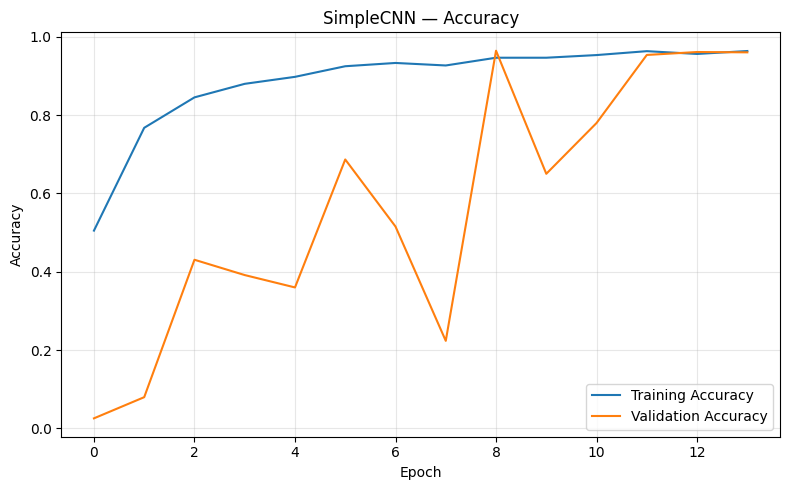

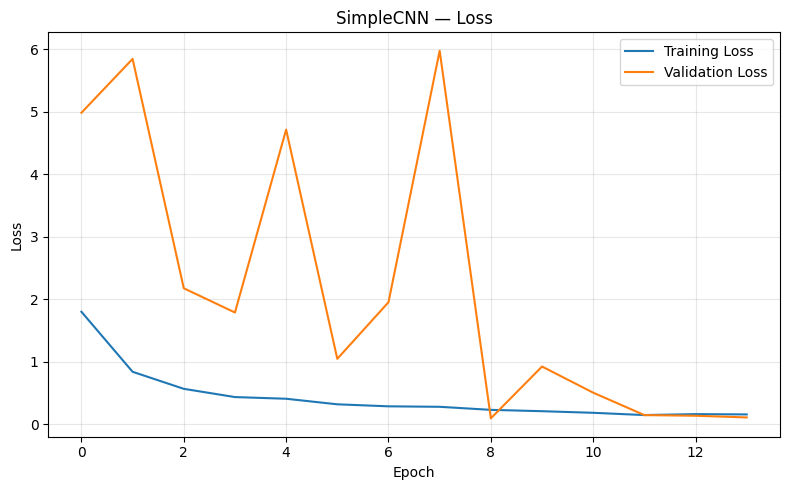


TEST EVALUATION — SimpleCNN
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step


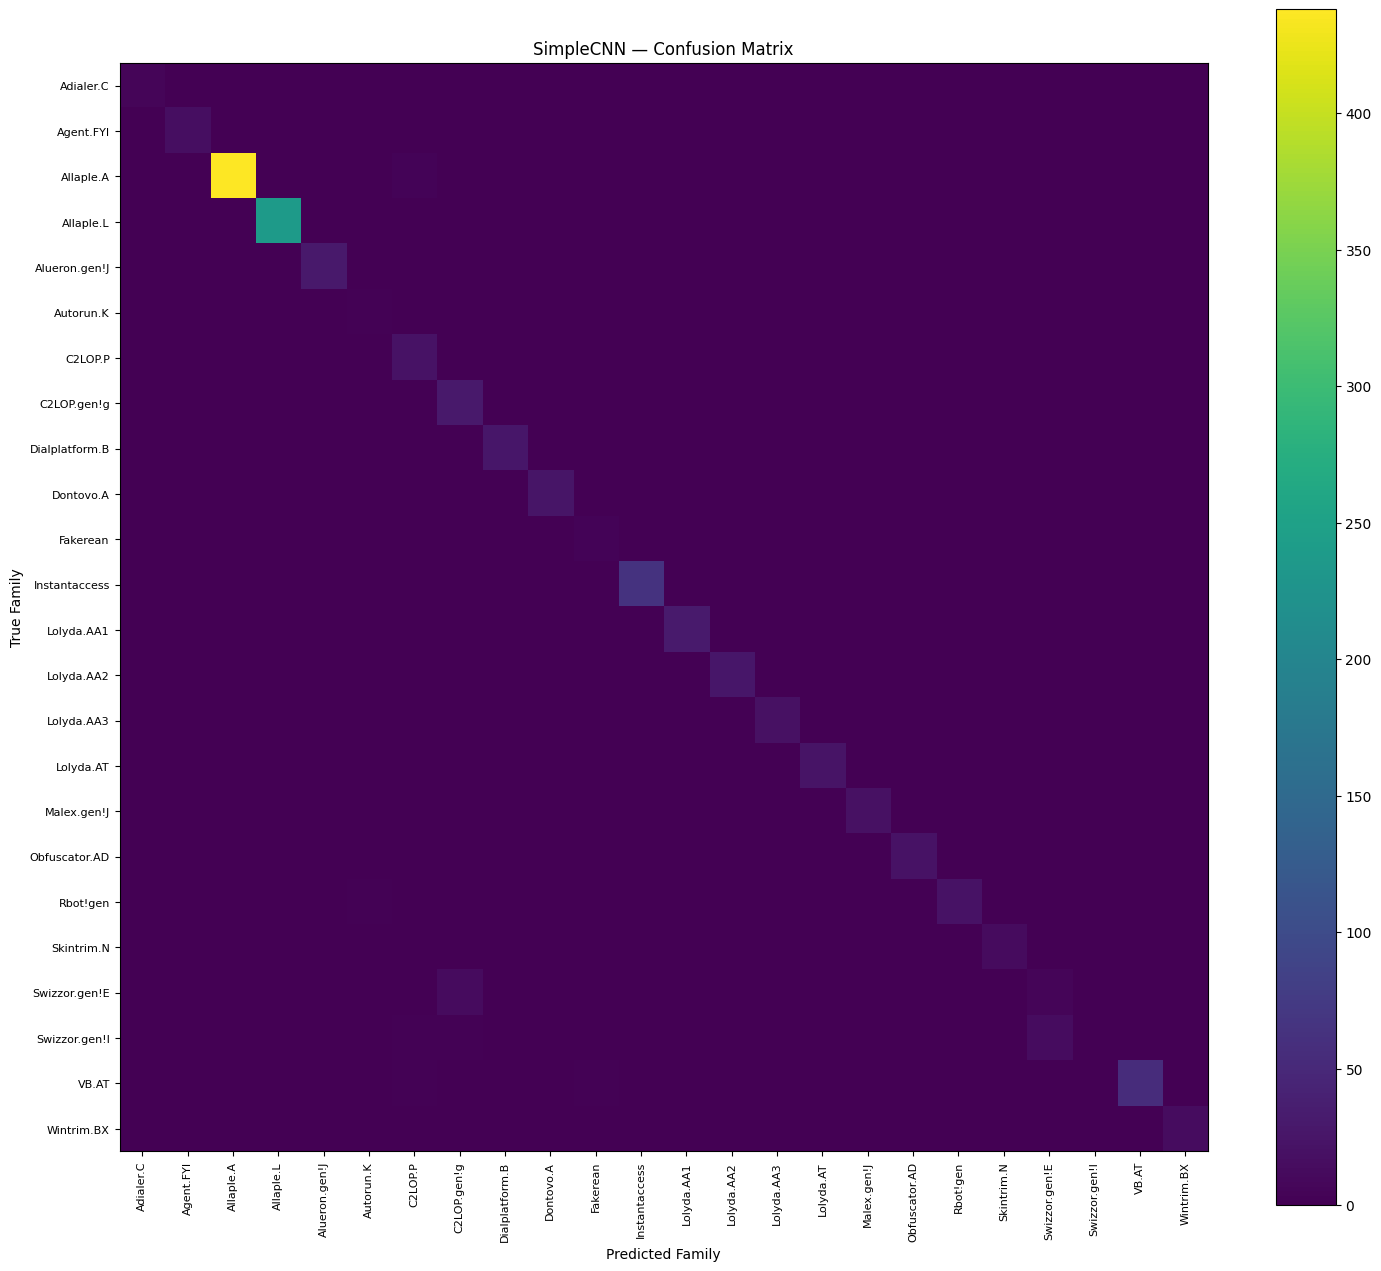


GLOBAL TEST METRICS
----------------------------------------------------------------------------------
Accuracy           : 0.9626
Macro Precision    : 0.9083
Macro Recall       : 0.9229
Macro F1           : 0.8908
Weighted Precision : 0.9710
Weighted Recall    : 0.9626
Weighted F1        : 0.9581

EFFICIENCY
----------------------------------------------------------------------------------
Training time      : 11.45 min
Epochs completed   : 14
Total parameters   : 307,960
Model size         : 3.64 MB
Inference          : 1.9828 ms/image

LOWEST PER-CLASS RECALL
----------------------------------------------------------------------------------
                precision    recall  f1-score  support
family                                                
Swizzor.gen!I    1.000000  0.050000  0.095238     20.0
Swizzor.gen!E    0.285714  0.315789  0.300000     19.0
Rbot!gen         0.954545  0.913043  0.933333     23.0
VB.AT            1.000000  0.918033  0.957265     61.0
Lolyda.AA2       

In [15]:
# ============================================================
# CELL 15
# TRAIN + EVALUATE BASELINE 1 — SIMPLE CNN
# ============================================================

(
    simple_cnn,
    simple_history,
    simple_result,
    simple_report,
    simple_per_class,
    simple_predictions
) = run_experiment(
    model=simple_cnn,
    model_name="SimpleCNN"
)

In [23]:
# ============================================================
# RESNET50 PRE-FLIGHT CHECK
# ============================================================

required_variables = [
    "IMG_HEIGHT",
    "IMG_WIDTH",
    "CHANNELS",
    "NUM_CLASSES",
    "train_ds",
    "val_ds",
    "test_ds",
    "class_weights",
    "create_augmentation",
    "run_experiment"
]

missing = [
    name
    for name in required_variables
    if name not in globals()
]

if missing:
    print("❌ Missing required notebook state:")
    
    for name in missing:
        print(" -", name)
        
    raise RuntimeError(
        "Rerun the setup cells before building ResNet50."
    )

print("✓ All ResNet50 prerequisites are available.")
print()
print("Image size :", IMG_HEIGHT, "x", IMG_WIDTH)
print("Channels   :", CHANNELS)
print("Classes    :", NUM_CLASSES)
print("Train size :", len(train_df))
print("Val size   :", len(val_df))
print("Test size  :", len(test_df))
print()
print("RESNET50 PRE-FLIGHT: PASSED ✓")

✓ All ResNet50 prerequisites are available.

Image size : 224 x 224
Channels   : 3
Classes    : 24
Train size : 5612
Val size   : 1203
Test size  : 1203

RESNET50 PRE-FLIGHT: PASSED ✓


In [24]:
# ============================================================
# CELL 16
# BASELINE 2 — RESNET50
#
# ImageNet pretrained convolutional backbone
# Backbone frozen for Task 2 baseline experiment
# ============================================================

print("=" * 82)
print("BASELINE 2 — RESNET50")
print("=" * 82)

tf.keras.backend.clear_session()


# ============================================================
# BUILD RESNET50 BASELINE
# ============================================================

def build_resnet50_baseline():

    # --------------------------------------------------------
    # Input
    # --------------------------------------------------------

    inputs = tf.keras.Input(
        shape=(
            IMG_HEIGHT,
            IMG_WIDTH,
            CHANNELS
        ),
        name="input_image"
    )

    # --------------------------------------------------------
    # SAME training augmentation policy
    # --------------------------------------------------------

    x = create_augmentation()(
        inputs
    )

    # --------------------------------------------------------
    # Our shared tf.data pipeline provides images in [0,1].
    #
    # ResNet50 preprocess_input expects image-scale values
    # corresponding to [0,255].
    #
    # Therefore:
    #
    # [0,1] → [0,255] → ResNet50 preprocessing
    # --------------------------------------------------------

    x = tf.keras.layers.Rescaling(
        scale=255.0,
        name="restore_0_255_range"
    )(x)

    x = tf.keras.layers.Lambda(
        tf.keras.applications.resnet50.preprocess_input,
        name="resnet50_preprocessing"
    )(x)

    # --------------------------------------------------------
    # Pretrained ResNet50 backbone
    # --------------------------------------------------------

    backbone = tf.keras.applications.ResNet50(
        include_top=False,
        weights="imagenet",
        input_shape=(
            IMG_HEIGHT,
            IMG_WIDTH,
            CHANNELS
        )
    )

    # --------------------------------------------------------
    # Task 2 transfer-learning baseline:
    # freeze convolutional backbone
    # --------------------------------------------------------

    backbone.trainable = False

    # --------------------------------------------------------
    # IMPORTANT:
    # training=False keeps BatchNorm layers in inference mode
    # while backbone is frozen.
    # --------------------------------------------------------

    x = backbone(
        x,
        training=False
    )

    # --------------------------------------------------------
    # Global feature aggregation
    # --------------------------------------------------------

    x = tf.keras.layers.GlobalAveragePooling2D(
        name="global_average_pooling"
    )(x)

    # --------------------------------------------------------
    # Common classifier head
    # --------------------------------------------------------

    x = tf.keras.layers.Dense(
        128,
        activation="relu",
        name="classifier_dense"
    )(x)

    x = tf.keras.layers.Dropout(
        0.40,
        name="classifier_dropout"
    )(x)

    outputs = tf.keras.layers.Dense(
        NUM_CLASSES,
        activation="softmax",
        name="family_predictions"
    )(x)

    # --------------------------------------------------------
    # Model
    # --------------------------------------------------------

    model = tf.keras.Model(
        inputs=inputs,
        outputs=outputs,
        name="ResNet50"
    )

    return model


# ============================================================
# CREATE MODEL
# ============================================================

resnet50_model = (
    build_resnet50_baseline()
)

resnet50_model.summary()


# ============================================================
# VERIFY BACKBONE STATUS
# ============================================================

resnet_backbone = None

for layer in resnet50_model.layers:

    if isinstance(
        layer,
        tf.keras.Model
    ) and "resnet50" in layer.name.lower():

        resnet_backbone = layer
        break


assert resnet_backbone is not None, (
    "ResNet50 backbone could not be identified."
)

print("\nBACKBONE VERIFICATION")
print("-" * 82)

print(
    "Backbone name      :",
    resnet_backbone.name
)

print(
    "Backbone trainable :",
    resnet_backbone.trainable
)

print(
    "Backbone params    :",
    f"{resnet_backbone.count_params():,}"
)

assert (
    resnet_backbone.trainable
    is False
)


# ============================================================
# OUTPUT CHECK
# ============================================================

dummy_input = tf.zeros(
    (
        1,
        IMG_HEIGHT,
        IMG_WIDTH,
        CHANNELS
    ),
    dtype=tf.float32
)

dummy_output = resnet50_model(
    dummy_input,
    training=False
)

print("\nMODEL VERIFICATION")
print("-" * 82)

print(
    "Input shape       :",
    dummy_input.shape
)

print(
    "Output shape      :",
    dummy_output.shape
)

print(
    "Evaluated classes :",
    NUM_CLASSES
)

print(
    "Total parameters  :",
    f"{resnet50_model.count_params():,}"
)

trainable_count = int(
    np.sum([
        np.prod(v.shape)
        for v in resnet50_model.trainable_weights
    ])
)

print(
    "Trainable params  :",
    f"{trainable_count:,}"
)

assert dummy_output.shape == (
    1,
    NUM_CLASSES
)

print("\n✓ ResNet50 architecture valid.")
print("✓ ImageNet pretrained backbone loaded.")
print("✓ ResNet50 backbone frozen.")
print("✓ Architecture-specific preprocessing included.")
print("✓ Output dimension matches 24 classes.")

BASELINE 2 — RESNET50
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "ResNet50"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ malimg_augmentation             │ (None, 224, 224, 3)    │             0 │
│ (Sequential)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ restore_0_255_range (Rescaling) │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50_preprocessing (Lambda) │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling          │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classifier_dense (Dense)        │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classifier_dropout (Dropout)    │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ family_predictions (Dense)      │ (None, 24)             │         3,096 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,853,080 (90.99 MB)

 Trainable params: 265,368 (1.01 MB)

 Non-trainable params: 23,587,712 (89.98 MB)


BACKBONE VERIFICATION
----------------------------------------------------------------------------------
Backbone name      : resnet50
Backbone trainable : False
Backbone params    : 23,587,712

MODEL VERIFICATION
----------------------------------------------------------------------------------
Input shape       : (1, 224, 224, 3)
Output shape      : (1, 24)
Evaluated classes : 24
Total parameters  : 23,853,080
Trainable params  : 265,368

✓ ResNet50 architecture valid.
✓ ImageNet pretrained backbone loaded.
✓ ResNet50 backbone frozen.
✓ Architecture-specific preprocessing included.
✓ Output dimension matches 24 classes.



STARTING EXPERIMENT — ResNet50


Model: "ResNet50"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ malimg_augmentation             │ (None, 224, 224, 3)    │             0 │
│ (Sequential)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ restore_0_255_range (Rescaling) │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50_preprocessing (Lambda) │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling          │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classifier_dense (Dense)        │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classifier_dropout (Dropout)    │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ family_predictions (Dense)      │ (None, 24)             │         3,096 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,853,080 (90.99 MB)

 Trainable params: 265,368 (1.01 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

Epoch 1/25
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step - accuracy: 0.7725 - loss: 0.7863
Epoch 1: val_loss improved from None to 0.26554, saving model to /kaggle/working/task2_outputs/baselines/ResNet50/ResNet50_best.keras

Epoch 1: finished saving model to /kaggle/working/task2_outputs/baselines/ResNet50/ResNet50_best.keras
176/176 ━━━━━━━━━━━━━━━━━━━━ 41s 184ms/step - accuracy: 0.8008 - loss: 0.6599 - val_accuracy: 0.9343 - val_loss: 0.2655 - learning_rate: 0.0010
Epoch 2/25
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step - accuracy: 0.8461 - loss: 0.5294
Epoch 2: val_loss did not improve from 0.26554
176/176 ━━━━━━━━━━━━━━━━━━━━ 27s 155ms/step - accuracy: 0.8599 - loss: 0.4337 - val_accuracy: 0.8919 - val_loss: 0.3376 - learning_rate: 0.0010
Epoch 3/25
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step - accuracy: 0.8821 - loss: 0.3495
Epoch 3: val_loss did not improve from 0.26554

Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
176/176 ━━━━━━━━━━━━━━━━━━━━ 27s 154ms/

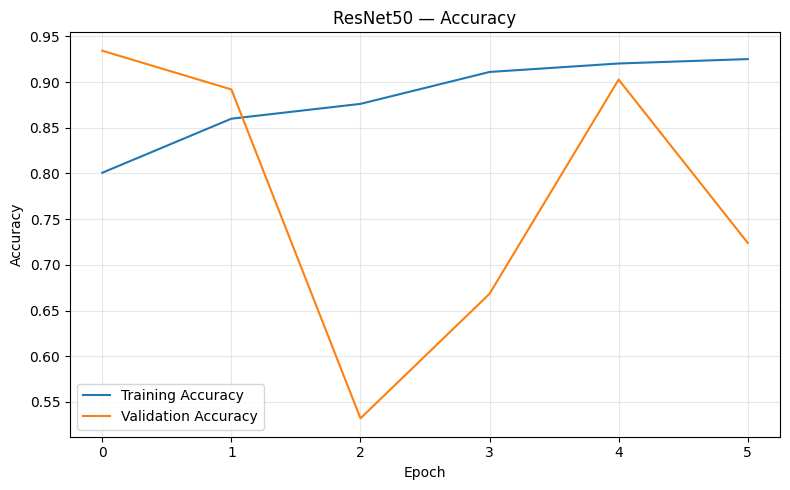

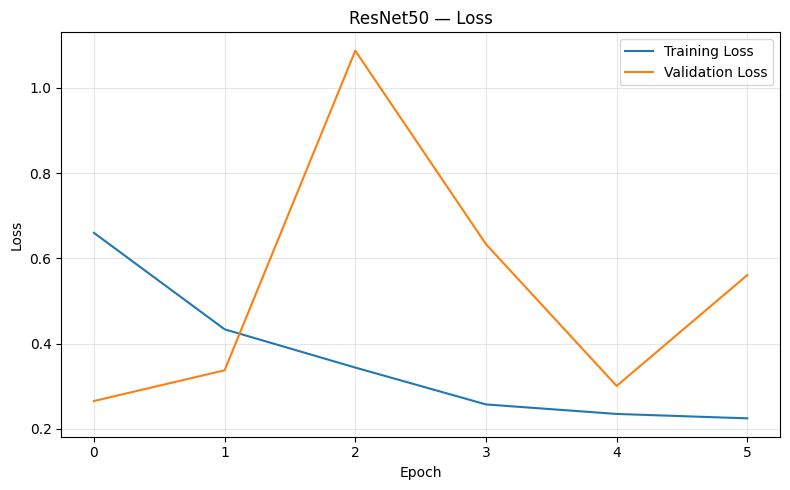


TEST EVALUATION — ResNet50
38/38 ━━━━━━━━━━━━━━━━━━━━ 9s 180ms/step


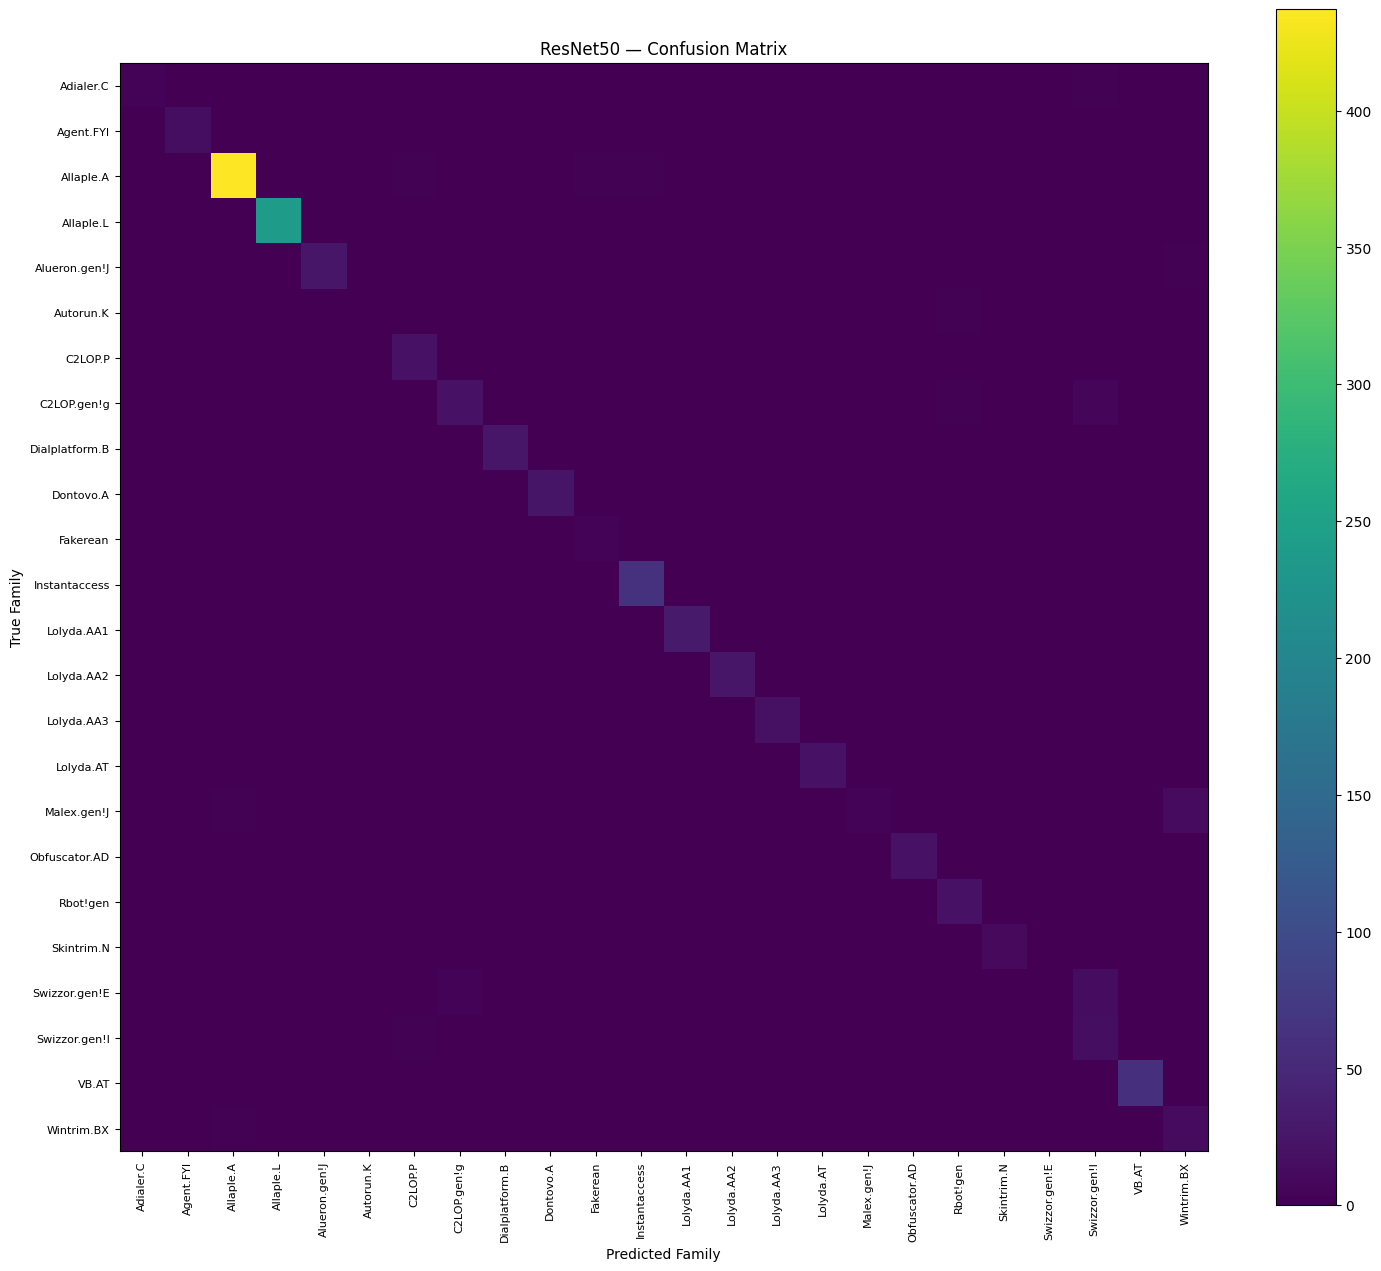


GLOBAL TEST METRICS
----------------------------------------------------------------------------------
Accuracy           : 0.9418
Macro Precision    : 0.8259
Macro Recall       : 0.8272
Macro F1           : 0.8079
Weighted Precision : 0.9442
Weighted Recall    : 0.9418
Weighted F1        : 0.9364

EFFICIENCY
----------------------------------------------------------------------------------
Training time      : 2.95 min
Epochs completed   : 6
Total parameters   : 23,853,080
Model size         : 93.67 MB
Inference          : 7.5889 ms/image

LOWEST PER-CLASS RECALL
----------------------------------------------------------------------------------
               precision    recall  f1-score  support
family                                               
Autorun.K       0.000000  0.000000  0.000000      2.0
Swizzor.gen!E   0.000000  0.000000  0.000000     19.0
Malex.gen!J     1.000000  0.250000  0.400000     20.0
Adialer.C       1.000000  0.666667  0.800000      6.0
C2LOP.gen!g     0.807

In [28]:
# ============================================================
# CELL 17
# TRAIN + EVALUATE BASELINE 2 — RESNET50
# ============================================================

(
    resnet50_model,
    resnet50_history,
    resnet50_result,
    resnet50_report,
    resnet50_per_class,
    resnet50_predictions
) = run_experiment(
    model=resnet50_model,
    model_name="ResNet50"
)

In [32]:
# ============================================================
# CELL 18
# BASELINE 3 — DENSENET121
#
# ImageNet pretrained backbone
# Frozen for the Task 2 baseline comparison
# ============================================================

print("=" * 82)
print("BASELINE 3 — DENSENET121")
print("=" * 82)

tf.keras.backend.clear_session()


# ============================================================
# BUILD DENSENET121 BASELINE
# ============================================================

def build_densenet121_baseline():

    # --------------------------------------------------------
    # Input
    # --------------------------------------------------------

    inputs = tf.keras.Input(
        shape=(
            IMG_HEIGHT,
            IMG_WIDTH,
            CHANNELS
        ),
        name="input_image"
    )

    # --------------------------------------------------------
    # Same training-only augmentation
    # --------------------------------------------------------

    x = create_augmentation()(
        inputs
    )

    # --------------------------------------------------------
    # Shared pipeline provides [0,1].
    #
    # DenseNet121 preprocess_input operates on image values
    # corresponding to the original image scale.
    #
    # Therefore:
    #
    # [0,1] → [0,255] → DenseNet preprocessing
    # --------------------------------------------------------

    x = tf.keras.layers.Rescaling(
        scale=255.0,
        name="restore_0_255_range"
    )(x)

    x = tf.keras.layers.Lambda(
        tf.keras.applications.densenet.preprocess_input,
        name="densenet121_preprocessing"
    )(x)

    # --------------------------------------------------------
    # ImageNet pretrained DenseNet121
    # --------------------------------------------------------

    backbone = tf.keras.applications.DenseNet121(
        include_top=False,
        weights="imagenet",
        input_shape=(
            IMG_HEIGHT,
            IMG_WIDTH,
            CHANNELS
        )
    )

    # Frozen backbone for Task 2
    backbone.trainable = False

    x = backbone(
        x,
        training=False
    )

    # --------------------------------------------------------
    # Global feature aggregation
    # --------------------------------------------------------

    x = tf.keras.layers.GlobalAveragePooling2D(
        name="global_average_pooling"
    )(x)

    # --------------------------------------------------------
    # Common classifier head
    # --------------------------------------------------------

    x = tf.keras.layers.Dense(
        128,
        activation="relu",
        name="classifier_dense"
    )(x)

    x = tf.keras.layers.Dropout(
        0.40,
        name="classifier_dropout"
    )(x)

    outputs = tf.keras.layers.Dense(
        NUM_CLASSES,
        activation="softmax",
        name="family_predictions"
    )(x)

    model = tf.keras.Model(
        inputs=inputs,
        outputs=outputs,
        name="DenseNet121"
    )

    return model


# ============================================================
# CREATE MODEL
# ============================================================

densenet121_model = (
    build_densenet121_baseline()
)

densenet121_model.summary()


# ============================================================
# FIND + VERIFY BACKBONE
# ============================================================

densenet_backbone = None

for layer in densenet121_model.layers:

    if isinstance(
        layer,
        tf.keras.Model
    ) and "densenet" in layer.name.lower():

        densenet_backbone = layer
        break


assert densenet_backbone is not None, (
    "DenseNet121 backbone could not be identified."
)

print("\nBACKBONE VERIFICATION")
print("-" * 82)

print(
    "Backbone name      :",
    densenet_backbone.name
)

print(
    "Backbone trainable :",
    densenet_backbone.trainable
)

print(
    "Backbone params    :",
    f"{densenet_backbone.count_params():,}"
)

assert densenet_backbone.trainable is False


# ============================================================
# OUTPUT VERIFICATION
# ============================================================

dummy_input = tf.zeros(
    (
        1,
        IMG_HEIGHT,
        IMG_WIDTH,
        CHANNELS
    ),
    dtype=tf.float32
)

dummy_output = densenet121_model(
    dummy_input,
    training=False
)

trainable_count = int(
    np.sum([
        np.prod(v.shape)
        for v
        in densenet121_model.trainable_weights
    ])
)

print("\nMODEL VERIFICATION")
print("-" * 82)

print(
    "Input shape       :",
    dummy_input.shape
)

print(
    "Output shape      :",
    dummy_output.shape
)

print(
    "Evaluated classes :",
    NUM_CLASSES
)

print(
    "Total parameters  :",
    f"{densenet121_model.count_params():,}"
)

print(
    "Trainable params  :",
    f"{trainable_count:,}"
)

assert dummy_output.shape == (
    1,
    NUM_CLASSES
)

print("\n✓ DenseNet121 architecture valid.")
print("✓ ImageNet pretrained backbone loaded.")
print("✓ DenseNet121 backbone frozen.")
print("✓ Architecture-specific preprocessing included.")
print("✓ Output dimension matches 24 evaluated classes.")

BASELINE 3 — DENSENET121
29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "DenseNet121"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ malimg_augmentation             │ (None, 224, 224, 3)    │             0 │
│ (Sequential)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ restore_0_255_range (Rescaling) │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet121_preprocessing       │ (None, 224, 224, 3)    │             0 │
│ (Lambda)                        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet121 (Functional)        │ (None, 7, 7, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling          │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classifier_dense (Dense)        │ (None, 128)            │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classifier_dropout (Dropout)    │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ family_predictions (Dense)      │ (None, 24)             │         3,096 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,171,800 (27.36 MB)

 Trainable params: 134,296 (524.59 KB)

 Non-trainable params: 7,037,504 (26.85 MB)


BACKBONE VERIFICATION
----------------------------------------------------------------------------------
Backbone name      : densenet121
Backbone trainable : False
Backbone params    : 7,037,504

MODEL VERIFICATION
----------------------------------------------------------------------------------
Input shape       : (1, 224, 224, 3)
Output shape      : (1, 24)
Evaluated classes : 24
Total parameters  : 7,171,800
Trainable params  : 134,296

✓ DenseNet121 architecture valid.
✓ ImageNet pretrained backbone loaded.
✓ DenseNet121 backbone frozen.
✓ Architecture-specific preprocessing included.
✓ Output dimension matches 24 evaluated classes.


TRAINING BASELINE 3 — DENSENET121

STARTING EXPERIMENT — DenseNet121


Model: "DenseNet121"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ malimg_augmentation             │ (None, 224, 224, 3)    │             0 │
│ (Sequential)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ restore_0_255_range (Rescaling) │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet121_preprocessing       │ (None, 224, 224, 3)    │             0 │
│ (Lambda)                        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet121 (Functional)        │ (None, 7, 7, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling          │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classifier_dense (Dense)        │ (None, 128)            │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classifier_dropout (Dropout)    │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ family_predictions (Dense)      │ (None, 24)             │         3,096 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,171,800 (27.36 MB)

 Trainable params: 134,296 (524.59 KB)

 Non-trainable params: 7,037,504 (26.85 MB)

Epoch 1/25
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step - accuracy: 0.3416 - loss: 2.3625
Epoch 1: val_loss improved from None to 0.70701, saving model to /kaggle/working/task2_outputs/baselines/DenseNet121/DenseNet121_best.keras

Epoch 1: finished saving model to /kaggle/working/task2_outputs/baselines/DenseNet121/DenseNet121_best.keras
176/176 ━━━━━━━━━━━━━━━━━━━━ 56s 226ms/step - accuracy: 0.4831 - loss: 1.7045 - val_accuracy: 0.8969 - val_loss: 0.7070 - learning_rate: 0.0010
Epoch 2/25
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step - accuracy: 0.7248 - loss: 0.7252
Epoch 2: val_loss improved from 0.70701 to 0.60029, saving model to /kaggle/working/task2_outputs/baselines/DenseNet121/DenseNet121_best.keras

Epoch 2: finished saving model to /kaggle/working/task2_outputs/baselines/DenseNet121/DenseNet121_best.keras
176/176 ━━━━━━━━━━━━━━━━━━━━ 32s 179ms/step - accuracy: 0.7315 - loss: 0.6630 - val_accuracy: 0.8371 - val_loss: 0.6003 - learning_rate: 0.0010
Epoch 3/25
176/176 ━━━━━━━━━━━━━━

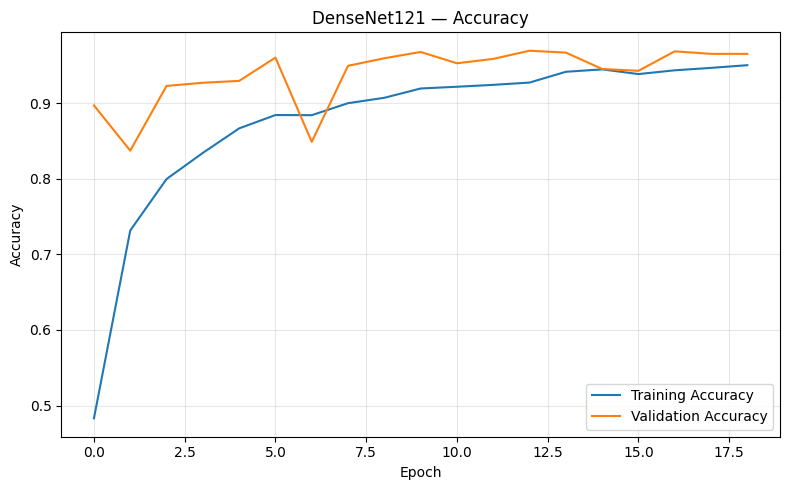

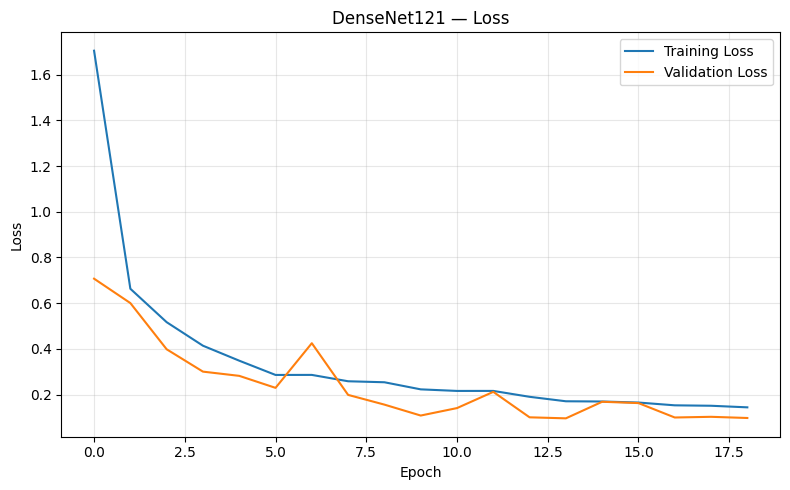


TEST EVALUATION — DenseNet121
38/38 ━━━━━━━━━━━━━━━━━━━━ 13s 243ms/step


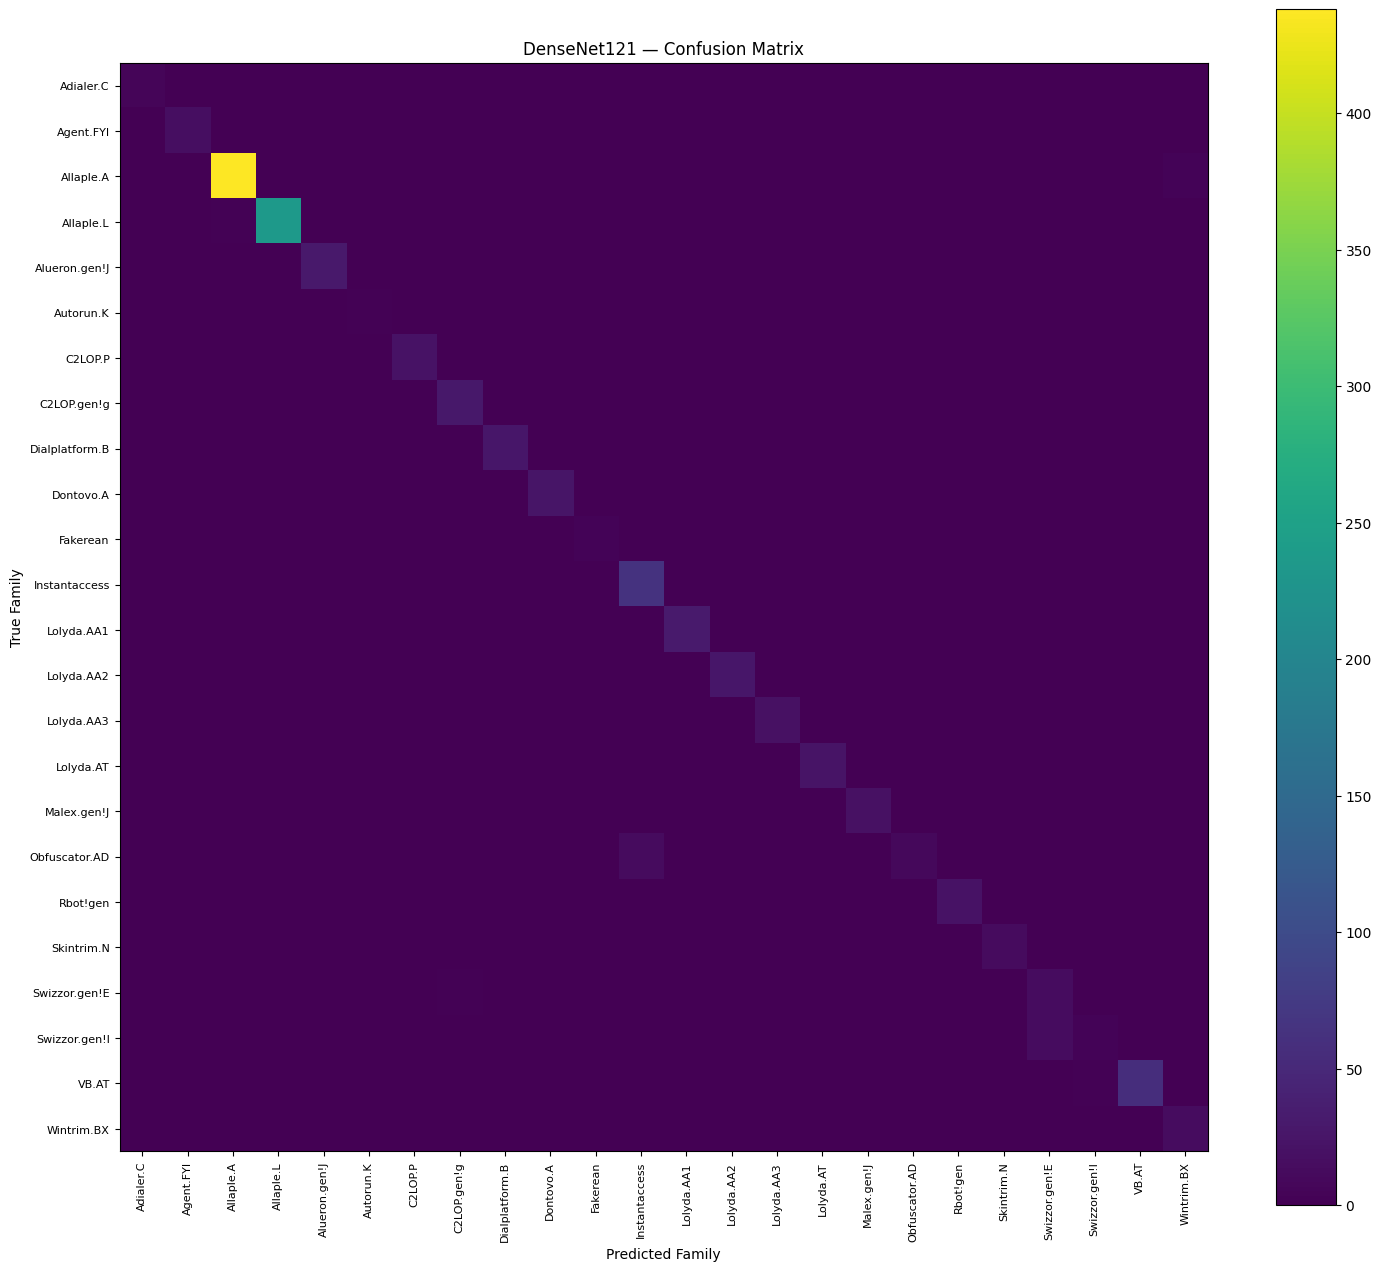


GLOBAL TEST METRICS
----------------------------------------------------------------------------------
Accuracy           : 0.9618
Macro Precision    : 0.9291
Macro Recall       : 0.9257
Macro F1           : 0.9188
Weighted Precision : 0.9639
Weighted Recall    : 0.9618
Weighted F1        : 0.9590

EFFICIENCY
----------------------------------------------------------------------------------
Training time      : 10.13 min
Epochs completed   : 19
Total parameters   : 7,171,800
Model size         : 29.85 MB
Inference          : 11.1784 ms/image

LOWEST PER-CLASS RECALL
----------------------------------------------------------------------------------
               precision    recall  f1-score  support
family                                               
Swizzor.gen!I   0.444444  0.200000  0.275862     20.0
Obfuscator.AD   1.000000  0.454545  0.625000     22.0
Swizzor.gen!E   0.517241  0.789474  0.625000     19.0
VB.AT           1.000000  0.950820  0.974790     61.0
C2LOP.P         0.9

In [33]:
# ============================================================
# CELL 19
# TRAIN + EVALUATE BASELINE 3 — DENSENET121
# ============================================================

print("=" * 82)
print("TRAINING BASELINE 3 — DENSENET121")
print("=" * 82)

(
    densenet121_model,
    densenet121_history,
    densenet121_result,
    densenet121_report,
    densenet121_per_class,
    densenet121_predictions
) = run_experiment(
    model=densenet121_model,
    model_name="DenseNet121"
)

print("\n" + "=" * 82)
print("DENSENET121 EXPERIMENT COMPLETE ✓")
print("=" * 82)

In [19]:
# ============================================================
# EFFICIENTNETB0 SESSION RECOVERY + PRE-FLIGHT
# ============================================================

import os
import json
import time
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

print("=" * 82)
print("EFFICIENTNETB0 SESSION RECOVERY CHECK")
print("=" * 82)

print("\nTensorFlow version:", tf.__version__)

required_variables = [
    "IMG_HEIGHT",
    "IMG_WIDTH",
    "CHANNELS",
    "NUM_CLASSES",
    "train_df",
    "val_df",
    "test_df",
    "train_ds",
    "val_ds",
    "test_ds",
    "class_weights",
    "create_augmentation",
    "run_experiment",
    "MAX_EPOCHS",
    "INITIAL_LR",
    "OUTPUT_DIR"
]

missing = [
    name
    for name in required_variables
    if name not in globals()
]

if missing:

    print("\n❌ Notebook state is incomplete.")
    print("\nMissing variables/functions:")

    for name in missing:
        print(" -", name)

    print(
        "\nRerun the NON-TRAINING setup cells listed below."
    )

else:

    print("\n✓ All EfficientNetB0 prerequisites are available.")

    print("\nCurrent experiment:")
    print(
        f"Image size : "
        f"{IMG_HEIGHT} × {IMG_WIDTH} × {CHANNELS}"
    )
    print(
        f"Classes    : {NUM_CLASSES}"
    )
    print(
        f"Train      : {len(train_df):,}"
    )
    print(
        f"Validation : {len(val_df):,}"
    )
    print(
        f"Test       : {len(test_df):,}"
    )

    print("\nEFFICIENTNETB0 PRE-FLIGHT: PASSED ✓")

EFFICIENTNETB0 SESSION RECOVERY CHECK

TensorFlow version: 2.20.0

✓ All EfficientNetB0 prerequisites are available.

Current experiment:
Image size : 224 × 224 × 3
Classes    : 24
Train      : 5,612
Validation : 1,203
Test       : 1,203

EFFICIENTNETB0 PRE-FLIGHT: PASSED ✓


In [20]:
# ============================================================
# CELL 20
# BASELINE 4 — EFFICIENTNETB0
#
# ImageNet pretrained backbone
# Frozen for Task 2 baseline comparison
# ============================================================

print("=" * 82)
print("BASELINE 4 — EFFICIENTNETB0")
print("=" * 82)

tf.keras.backend.clear_session()


# ============================================================
# BUILD EFFICIENTNETB0 BASELINE
# ============================================================

def build_efficientnetb0_baseline():

    # --------------------------------------------------------
    # Input
    # --------------------------------------------------------

    inputs = tf.keras.Input(
        shape=(
            IMG_HEIGHT,
            IMG_WIDTH,
            CHANNELS
        ),
        name="input_image"
    )

    # --------------------------------------------------------
    # Same training-only augmentation
    # --------------------------------------------------------

    x = create_augmentation()(
        inputs
    )

    # --------------------------------------------------------
    # Shared pipeline provides [0,1].
    #
    # Keras EfficientNet contains its own input preprocessing
    # and is designed for image-scale values corresponding
    # to [0,255].
    #
    # Therefore:
    #
    # [0,1] → [0,255] → EfficientNetB0
    # --------------------------------------------------------

    x = tf.keras.layers.Rescaling(
        scale=255.0,
        name="restore_0_255_range"
    )(x)

    # --------------------------------------------------------
    # ImageNet pretrained EfficientNetB0
    # --------------------------------------------------------

    backbone = tf.keras.applications.EfficientNetB0(
        include_top=False,
        weights="imagenet",
        input_shape=(
            IMG_HEIGHT,
            IMG_WIDTH,
            CHANNELS
        )
    )

    # --------------------------------------------------------
    # Freeze backbone for Task 2
    # --------------------------------------------------------

    backbone.trainable = False

    x = backbone(
        x,
        training=False
    )

    # --------------------------------------------------------
    # Global feature aggregation
    # --------------------------------------------------------

    x = tf.keras.layers.GlobalAveragePooling2D(
        name="global_average_pooling"
    )(x)

    # --------------------------------------------------------
    # Same classifier head
    # --------------------------------------------------------

    x = tf.keras.layers.Dense(
        128,
        activation="relu",
        name="classifier_dense"
    )(x)

    x = tf.keras.layers.Dropout(
        0.40,
        name="classifier_dropout"
    )(x)

    outputs = tf.keras.layers.Dense(
        NUM_CLASSES,
        activation="softmax",
        name="family_predictions"
    )(x)

    model = tf.keras.Model(
        inputs=inputs,
        outputs=outputs,
        name="EfficientNetB0"
    )

    return model


# ============================================================
# CREATE MODEL
# ============================================================

efficientnetb0_model = (
    build_efficientnetb0_baseline()
)

efficientnetb0_model.summary()


# ============================================================
# FIND + VERIFY BACKBONE
# ============================================================

efficientnet_backbone = None

for layer in efficientnetb0_model.layers:

    if isinstance(
        layer,
        tf.keras.Model
    ) and "efficientnet" in layer.name.lower():

        efficientnet_backbone = layer
        break


assert efficientnet_backbone is not None, (
    "EfficientNetB0 backbone could not be identified."
)

print("\nBACKBONE VERIFICATION")
print("-" * 82)

print(
    "Backbone name      :",
    efficientnet_backbone.name
)

print(
    "Backbone trainable :",
    efficientnet_backbone.trainable
)

print(
    "Backbone params    :",
    f"{efficientnet_backbone.count_params():,}"
)

assert (
    efficientnet_backbone.trainable
    is False
)


# ============================================================
# OUTPUT VERIFICATION
# ============================================================

dummy_input = tf.zeros(
    (
        1,
        IMG_HEIGHT,
        IMG_WIDTH,
        CHANNELS
    ),
    dtype=tf.float32
)

dummy_output = efficientnetb0_model(
    dummy_input,
    training=False
)

trainable_count = int(
    np.sum([
        np.prod(v.shape)
        for v
        in efficientnetb0_model.trainable_weights
    ])
)

print("\nMODEL VERIFICATION")
print("-" * 82)

print(
    "Input shape       :",
    dummy_input.shape
)

print(
    "Output shape      :",
    dummy_output.shape
)

print(
    "Evaluated classes :",
    NUM_CLASSES
)

print(
    "Total parameters  :",
    f"{efficientnetb0_model.count_params():,}"
)

print(
    "Trainable params  :",
    f"{trainable_count:,}"
)

assert dummy_output.shape == (
    1,
    NUM_CLASSES
)

print("\n✓ EfficientNetB0 architecture valid.")
print("✓ ImageNet pretrained backbone loaded.")
print("✓ EfficientNetB0 backbone frozen.")
print("✓ Input restored from [0,1] to [0,255].")
print("✓ EfficientNet internal preprocessing retained.")
print("✓ Output dimension matches 24 evaluated classes.")

BASELINE 4 — EFFICIENTNETB0
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "EfficientNetB0"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ malimg_augmentation             │ (None, 224, 224, 3)    │             0 │
│ (Sequential)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ restore_0_255_range (Rescaling) │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling          │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classifier_dense (Dense)        │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classifier_dropout (Dropout)    │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ family_predictions (Dense)      │ (None, 24)             │         3,096 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,216,635 (16.09 MB)

 Trainable params: 167,064 (652.59 KB)

 Non-trainable params: 4,049,571 (15.45 MB)


BACKBONE VERIFICATION
----------------------------------------------------------------------------------
Backbone name      : efficientnetb0
Backbone trainable : False
Backbone params    : 4,049,571

MODEL VERIFICATION
----------------------------------------------------------------------------------
Input shape       : (1, 224, 224, 3)
Output shape      : (1, 24)
Evaluated classes : 24
Total parameters  : 4,216,635
Trainable params  : 167,064

✓ EfficientNetB0 architecture valid.
✓ ImageNet pretrained backbone loaded.
✓ EfficientNetB0 backbone frozen.
✓ Input restored from [0,1] to [0,255].
✓ EfficientNet internal preprocessing retained.
✓ Output dimension matches 24 evaluated classes.


TRAINING BASELINE 4 — EFFICIENTNETB0

STARTING EXPERIMENT — EfficientNetB0


Model: "EfficientNetB0"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ malimg_augmentation             │ (None, 224, 224, 3)    │             0 │
│ (Sequential)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ restore_0_255_range (Rescaling) │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling          │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classifier_dense (Dense)        │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classifier_dropout (Dropout)    │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ family_predictions (Dense)      │ (None, 24)             │         3,096 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,216,635 (16.09 MB)

 Trainable params: 167,064 (652.59 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

Epoch 1/25


E0000 00:00:1787147784.282296      58 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/EfficientNetB0_1/efficientnetb0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.4531 - loss: 1.9940
Epoch 1: val_loss improved from None to 0.73720, saving model to /kaggle/working/task2_outputs/baselines/EfficientNetB0/EfficientNetB0_best.keras

Epoch 1: finished saving model to /kaggle/working/task2_outputs/baselines/EfficientNetB0/EfficientNetB0_best.keras
176/176 ━━━━━━━━━━━━━━━━━━━━ 32s 114ms/step - accuracy: 0.5966 - loss: 1.4228 - val_accuracy: 0.6800 - val_loss: 0.7372 - learning_rate: 0.0010
Epoch 2/25
175/176 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.7743 - loss: 0.6387
Epoch 2: val_loss improved from 0.73720 to 0.45827, saving model to /kaggle/working/task2_outputs/baselines/EfficientNetB0/EfficientNetB0_best.keras

Epoch 2: finished saving model to /kaggle/working/task2_outputs/baselines/EfficientNetB0/EfficientNetB0_best.keras
176/176 ━━━━━━━━━━━━━━━━━━━━ 16s 92ms/step - accuracy: 0.7890 - loss: 0.5861 - val_accuracy: 0.8994 - val_loss: 0.4583 - learning_rate: 0.0010
Epoch 3/25
175/176 ━━━━

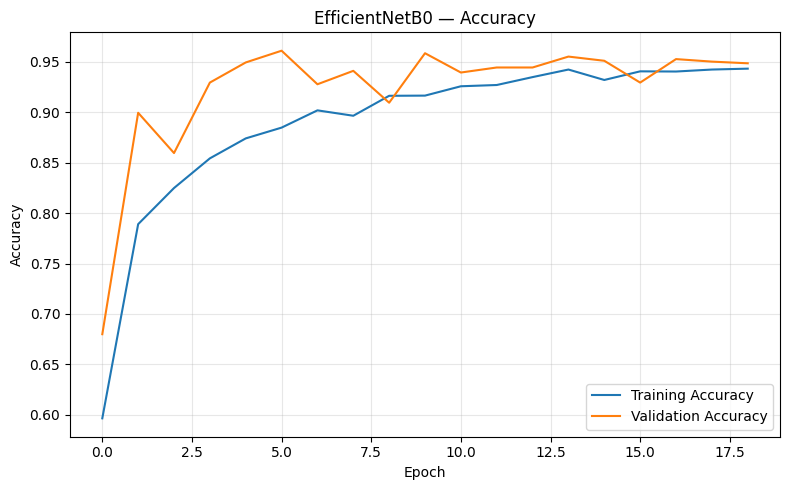

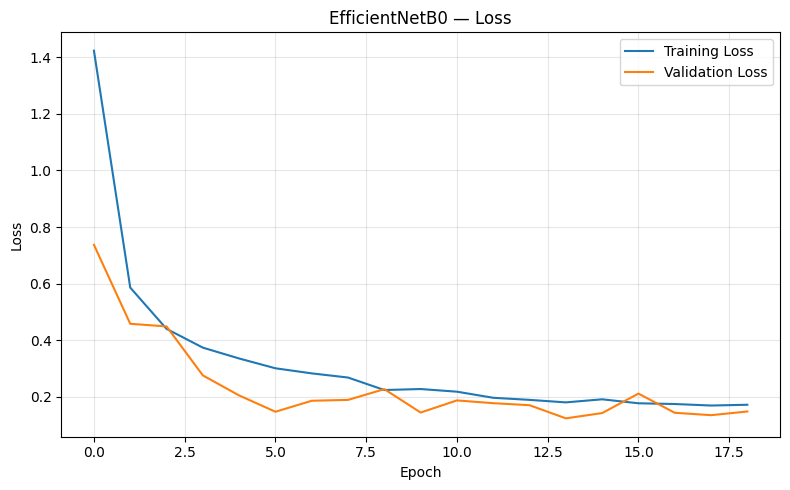


TEST EVALUATION — EfficientNetB0
38/38 ━━━━━━━━━━━━━━━━━━━━ 7s 132ms/step


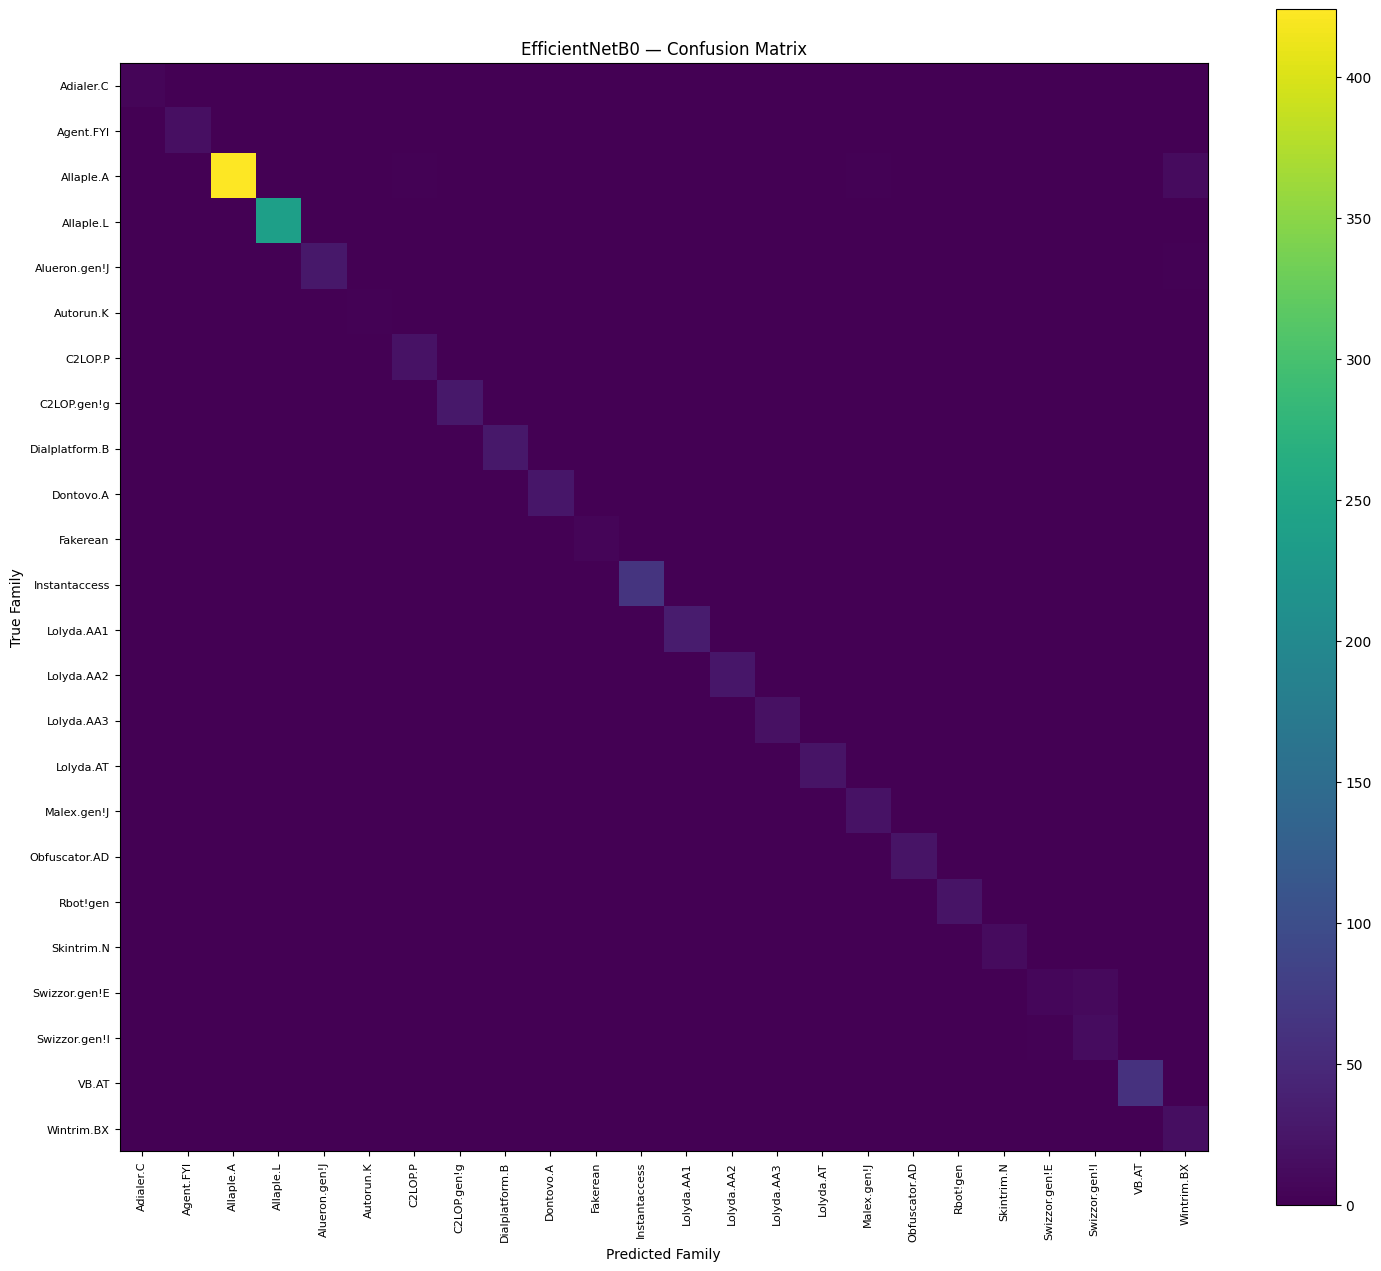


GLOBAL TEST METRICS
----------------------------------------------------------------------------------
Accuracy           : 0.9626
Macro Precision    : 0.9233
Macro Recall       : 0.9479
Macro F1           : 0.9296
Weighted Precision : 0.9697
Weighted Recall    : 0.9626
Weighted F1        : 0.9639

EFFICIENCY
----------------------------------------------------------------------------------
Training time      : 5.43 min
Epochs completed   : 19
Total parameters   : 4,216,635
Model size         : 18.18 MB
Inference          : 6.0182 ms/image

LOWEST PER-CLASS RECALL
----------------------------------------------------------------------------------
                precision    recall  f1-score  support
family                                                
Swizzor.gen!E    0.636364  0.368421  0.466667     19.0
Swizzor.gen!I    0.560000  0.700000  0.622222     20.0
C2LOP.gen!g      0.933333  0.933333  0.933333     30.0
Alueron.gen!J    0.965517  0.933333  0.949153     30.0
C2LOP.P        

In [21]:
# ============================================================
# CELL 21
# TRAIN + EVALUATE BASELINE 4 — EFFICIENTNETB0
# ============================================================

print("=" * 82)
print("TRAINING BASELINE 4 — EFFICIENTNETB0")
print("=" * 82)

(
    efficientnetb0_model,
    efficientnetb0_history,
    efficientnetb0_result,
    efficientnetb0_report,
    efficientnetb0_per_class,
    efficientnetb0_predictions
) = run_experiment(
    model=efficientnetb0_model,
    model_name="EfficientNetB0"
)

print("\n" + "=" * 82)
print("EFFICIENTNETB0 EXPERIMENT COMPLETE ✓")
print("=" * 82)

OFFICIAL TASK 2 — CNN BASELINE COMPARISON

✓ All four baseline metric files loaded.

----------------------------------------------------------------------------------------
BASELINE PERFORMANCE
----------------------------------------------------------------------------------------
         model accuracy macro_precision macro_recall macro_f1 weighted_f1  macro_f1_rank
EfficientNetB0   96.26%          92.33%       94.79%   92.96%      96.39%              1
   DenseNet121   96.18%          92.91%       92.57%   91.88%      95.90%              2
     SimpleCNN   96.26%          90.83%       92.29%   89.08%      95.81%              3
      ResNet50   94.18%          82.59%       82.72%   80.79%      93.64%              4

----------------------------------------------------------------------------------------
BASELINE EFFICIENCY
----------------------------------------------------------------------------------------
         model total_params model_size_mb training_time_minutes inferenc

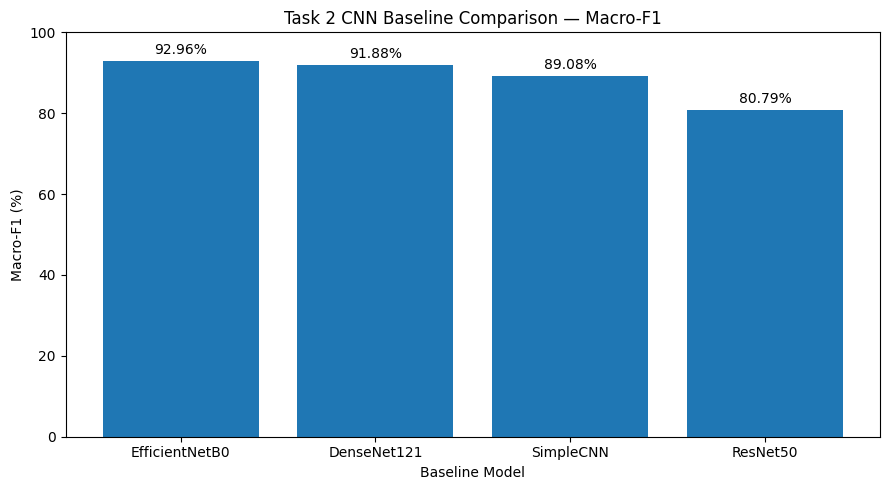

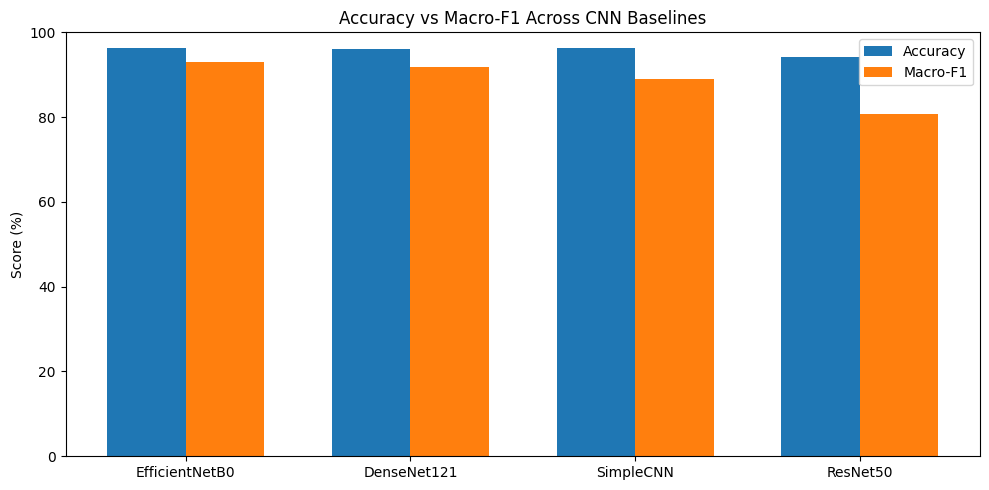


Saved:
Baseline table       : /kaggle/working/task2_outputs/FINAL_baseline_comparison.csv
Macro-F1 figure      : /kaggle/working/task2_outputs/baseline_macro_f1_comparison.png
Accuracy/F1 figure   : /kaggle/working/task2_outputs/baseline_accuracy_vs_macro_f1.png

FOUR CNN BASELINES COMPLETE ✓


In [22]:
# ============================================================
# CELL 22
# OFFICIAL FOUR-BASELINE COMPARISON
#
# Reloads saved experimental results from disk.
# This remains valid even after a kernel restart.
# ============================================================

print("=" * 88)
print("OFFICIAL TASK 2 — CNN BASELINE COMPARISON")
print("=" * 88)

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Baselines evaluated in Task 2
# ------------------------------------------------------------

BASELINE_NAMES = [
    "SimpleCNN",
    "ResNet50",
    "DenseNet121",
    "EfficientNetB0"
]

baseline_rows = []

# ============================================================
# PART 1 — LOAD SAVED RESULTS
# ============================================================

for model_name in BASELINE_NAMES:

    metrics_path = (
        OUTPUT_DIR
        / "baselines"
        / model_name
        / f"{model_name}_metrics.json"
    )

    if not metrics_path.exists():

        raise FileNotFoundError(
            f"Missing metrics file:\n{metrics_path}"
        )

    with open(
        metrics_path,
        "r"
    ) as f:

        metrics = json.load(f)

    baseline_rows.append(
        metrics
    )

print(
    "\n✓ All four baseline metric files loaded."
)

# ============================================================
# PART 2 — MASTER RESULT DATAFRAME
# ============================================================

baseline_comparison_df = pd.DataFrame(
    baseline_rows
)

# Keep important columns in report order
comparison_columns = [

    "model",

    "accuracy",

    "macro_precision",
    "macro_recall",
    "macro_f1",

    "weighted_precision",
    "weighted_recall",
    "weighted_f1",

    "training_time_minutes",
    "epochs_completed",

    "total_params",
    "trainable_params",

    "model_size_mb",

    "inference_ms_per_image"
]

baseline_comparison_df = (
    baseline_comparison_df[
        comparison_columns
    ]
)

# ============================================================
# PART 3 — RANK BY MANDATORY PRIMARY METRIC
# ============================================================

baseline_comparison_df[
    "macro_f1_rank"
] = (
    baseline_comparison_df[
        "macro_f1"
    ]
    .rank(
        method="min",
        ascending=False
    )
    .astype(int)
)

baseline_comparison_df = (
    baseline_comparison_df
    .sort_values(
        "macro_f1",
        ascending=False
    )
    .reset_index(drop=True)
)

# ============================================================
# PART 4 — DISPLAY PERCENTAGE TABLE
# ============================================================

display_df = (
    baseline_comparison_df.copy()
)

percentage_columns = [
    "accuracy",
    "macro_precision",
    "macro_recall",
    "macro_f1",
    "weighted_precision",
    "weighted_recall",
    "weighted_f1"
]

for col in percentage_columns:

    display_df[col] = (
        display_df[col] * 100
    )

print("\n" + "-" * 88)
print("BASELINE PERFORMANCE")
print("-" * 88)

print(
    display_df[
        [
            "model",
            "accuracy",
            "macro_precision",
            "macro_recall",
            "macro_f1",
            "weighted_f1",
            "macro_f1_rank"
        ]
    ].to_string(
        index=False,
        formatters={
            "accuracy":
                lambda x: f"{x:.2f}%",
            "macro_precision":
                lambda x: f"{x:.2f}%",
            "macro_recall":
                lambda x: f"{x:.2f}%",
            "macro_f1":
                lambda x: f"{x:.2f}%",
            "weighted_f1":
                lambda x: f"{x:.2f}%"
        }
    )
)

# ============================================================
# PART 5 — EFFICIENCY TABLE
# ============================================================

print("\n" + "-" * 88)
print("BASELINE EFFICIENCY")
print("-" * 88)

print(
    baseline_comparison_df[
        [
            "model",
            "total_params",
            "model_size_mb",
            "training_time_minutes",
            "inference_ms_per_image",
            "epochs_completed"
        ]
    ].to_string(
        index=False,
        formatters={
            "total_params":
                lambda x: f"{int(x):,}",
            "model_size_mb":
                lambda x: f"{x:.2f}",
            "training_time_minutes":
                lambda x: f"{x:.2f}",
            "inference_ms_per_image":
                lambda x: f"{x:.4f}"
        }
    )
)

# ============================================================
# PART 6 — IDENTIFY BEST BASELINE
# ============================================================

best_baseline = (
    baseline_comparison_df.iloc[0]
)

BEST_BASELINE_NAME = (
    best_baseline["model"]
)

BEST_BASELINE_MACRO_F1 = float(
    best_baseline["macro_f1"]
)

BEST_BASELINE_ACCURACY = float(
    best_baseline["accuracy"]
)

BEST_BASELINE_MACRO_RECALL = float(
    best_baseline["macro_recall"]
)

print("\n" + "=" * 88)
print("BEST BASELINE — PRIMARY METRIC")
print("=" * 88)

print(
    f"Model        : "
    f"{BEST_BASELINE_NAME}"
)

print(
    f"Macro-F1     : "
    f"{BEST_BASELINE_MACRO_F1 * 100:.2f}%"
)

print(
    f"Macro Recall : "
    f"{BEST_BASELINE_MACRO_RECALL * 100:.2f}%"
)

print(
    f"Accuracy     : "
    f"{BEST_BASELINE_ACCURACY * 100:.2f}%"
)

assert (
    BEST_BASELINE_NAME
    == "EfficientNetB0"
)

print(
    "\n✓ EfficientNetB0 is the best Task 2 "
    "baseline according to Macro-F1."
)

# ============================================================
# PART 7 — MACRO-F1 COMPARISON FIGURE
# ============================================================

plot_df = (
    baseline_comparison_df
    .sort_values(
        "macro_f1",
        ascending=False
    )
)

plt.figure(
    figsize=(9, 5)
)

bars = plt.bar(
    plot_df["model"],
    plot_df["macro_f1"] * 100
)

plt.ylabel(
    "Macro-F1 (%)"
)

plt.xlabel(
    "Baseline Model"
)

plt.title(
    "Task 2 CNN Baseline Comparison — Macro-F1"
)

plt.ylim(
    0,
    100
)

for bar, score in zip(
    bars,
    plot_df["macro_f1"]
):

    plt.text(
        bar.get_x()
        + bar.get_width() / 2,

        bar.get_height() + 1,

        f"{score * 100:.2f}%",

        ha="center",
        va="bottom"
    )

plt.tight_layout()

macro_f1_plot_path = (
    OUTPUT_DIR /
    "baseline_macro_f1_comparison.png"
)

plt.savefig(
    macro_f1_plot_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ============================================================
# PART 8 — ACCURACY VS MACRO-F1 FIGURE
# ============================================================

comparison_plot_df = (
    baseline_comparison_df[
        [
            "model",
            "accuracy",
            "macro_f1"
        ]
    ]
    .copy()
)

x = np.arange(
    len(comparison_plot_df)
)

width = 0.35

plt.figure(
    figsize=(10, 5)
)

plt.bar(
    x - width / 2,
    comparison_plot_df["accuracy"] * 100,
    width,
    label="Accuracy"
)

plt.bar(
    x + width / 2,
    comparison_plot_df["macro_f1"] * 100,
    width,
    label="Macro-F1"
)

plt.xticks(
    x,
    comparison_plot_df["model"]
)

plt.ylabel(
    "Score (%)"
)

plt.title(
    "Accuracy vs Macro-F1 Across CNN Baselines"
)

plt.ylim(
    0,
    100
)

plt.legend()

plt.tight_layout()

accuracy_macro_plot_path = (
    OUTPUT_DIR /
    "baseline_accuracy_vs_macro_f1.png"
)

plt.savefig(
    accuracy_macro_plot_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ============================================================
# PART 9 — SAVE OFFICIAL BASELINE TABLE
# ============================================================

baseline_csv_path = (
    OUTPUT_DIR /
    "FINAL_baseline_comparison.csv"
)

baseline_comparison_df.to_csv(
    baseline_csv_path,
    index=False
)

print("\nSaved:")
print(
    "Baseline table       :",
    baseline_csv_path
)

print(
    "Macro-F1 figure      :",
    macro_f1_plot_path
)

print(
    "Accuracy/F1 figure   :",
    accuracy_macro_plot_path
)

print("\n" + "=" * 88)
print("FOUR CNN BASELINES COMPLETE ✓")
print("=" * 88)